# HyGal Dirty Spectra
### Topic: Calibrating the N(OH), Tau of 18cm radio lines with IR data (SOFIA).

#### First we wil try to plot the spectra and zoom in.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import matplotlib.backends.backend_pdf
import celerite
import glob

from astropy.io import fits

from astropy import units as u
from astropy import constants as const
from astropy.modeling import models, fitting
from astropy.table import QTable, Table, Column, vstack

from IPython.display import Image
import OHfunc as O

from specutils import Spectrum1D, SpectralRegion
from specutils.fitting import find_lines_threshold
from astropy.nddata import StdDevUncertainty
from astropy.modeling import models, fitting
from specutils.manipulation import noise_region_uncertainty

from specutils.fitting import estimate_line_parameters
from specutils.manipulation import extract_region
from specutils.fitting import fit_lines

from astropy.modeling.fitting import LevMarLSQFitter
fit = LevMarLSQFitter()

In [2]:
# Function calls:

def gaussFit(Ta, Vel, amp, mean, stdev=1):
    gaussFit = models.Gaussian1D(amplitude=amp, mean=mean, stddev=stdev)
    y_fit = fit(gaussFit, Vel*u.km/u.s, ((Ta-Tc)/Tc)*u.K)
    y_pred = y_fit(Vel*u.km/u.s)
    amp = y_fit.amplitude[0]*u.K
    mean = y_fit.mean[0]*u.km/u.s
    stddev = y_fit.stddev[0]*u.km/u.s
    return y_pred, amp, mean, stddev

def EWfunc(Ta, Vel, mean, FWHM, dv):
    
    igood = np.where((Vel >= -100) & (Vel <= 40))
    
    # Reload Data:
    velc = Vel[igood]
    Tac = Ta[igood]

    Tc = np.median(Tac)
    Tcsigma = np.std(Tac)
    sigmaEW = np.std((Tac - Tc)/Tc)
    
    # Choose Velocity Range to integrate:
    igood = np.where((Vel >= mean-FWHM) & (Vel <= mean+FWHM))
    TaEW = Ta[igood]
    EW = np.sum(((TaEW-Tc)/Tc)*dv)
    
    return EW, Tc, sigmaEW, Tcsigma

In [3]:
oh = ascii.read("DirtySpectra/w51/w51-1667.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'])

vel = oh['VELO (km/s)']
Ta = oh['Ta (K)']

In [4]:
# header
#title: Spectral profile - W51_22.image.pbcor-raster
#region (world): Ellipse[[19:23:44.278, +14d30m25.499], [19:23:43.521, +14d30m36.499]]
#region (pixel): Ellipse[[198, 198], [201, 201]]
#coordinate: world
#xLabel: radio velocity [km/s]
#yLabel: [Kelvin] Mean

In [5]:
# Measure continuum:

# Choose velocity range.
igood = np.where((vel >= -50) & (vel <= -10))

vel = vel[igood]
Ta = Ta[igood]

Tc = np.mean(Ta)
print(Tc)
Tcerr = print(Tc/np.sqrt(len(Ta)))

3728.947807498123
582.3638069832515


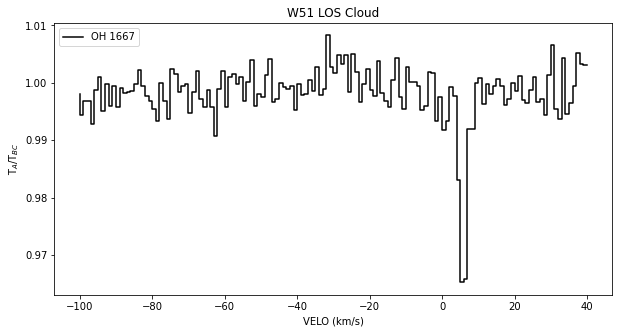

In [6]:
vel = oh['VELO (km/s)']
Ta = oh['Ta (K)']

# Choose velocity range.
igood = np.where((vel >= -100) & (vel <= 40))

vel = vel[igood]
Ta = Ta[igood]

# Plot the data:
fig, ax1 = plt.subplots(1, figsize=(10, 5))

# Plot the xx:
ax1.step(vel, Ta/Tc, 'k', label='OH 1667')
ax1.set_title('W51 LOS Cloud')
ax1.set_xlabel('VELO (km/s)')
ax1.set_ylabel(r'T$_{A}$/T$_{BC}$')
ax1.legend()
#ax1.set_ylim([0.95, 1.05])
#ax1.axvline(7.2, color='k', ls='dashed')

In [7]:
# Let's plot all of the lines:

In [8]:
oh67 = ascii.read("DirtySpectra/w51/w51-1667.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'])
oh65 = ascii.read("DirtySpectra/w51/w51-1665.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'])
oh12 = ascii.read("DirtySpectra/w51/w51-1612.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'])
oh20 = ascii.read("DirtySpectra/w51/w51-1720.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'])

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']

vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']

vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']

vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']

# Choose velocity range.
igood = np.where((vel67 >= -100) & (vel67 <= 40))

# Get data ranges:

vel67 = vel67[igood]
Ta67 = Ta67[igood]

vel65 = vel65[igood]
Ta65 = Ta65[igood]

vel12 = vel12[igood]
Ta12 = Ta12[igood]

vel20 = vel20[igood]
Ta20 = Ta20[igood]

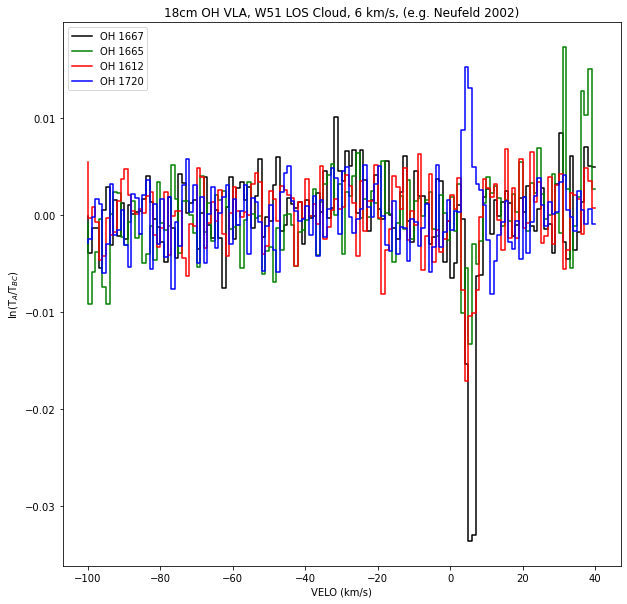

In [9]:
# Plot the data:
fig, ax1 = plt.subplots(1, figsize=(10, 10))

# Plot the xx:
ax1.step(vel67, np.log(Ta67/np.mean(Ta67)), 'k', label='OH 1667')
ax1.step(vel65, np.log(Ta65/np.mean(Ta65)), 'g', label='OH 1665')
ax1.step(vel12, np.log(Ta12/np.mean(Ta12)), 'r', label='OH 1612')
ax1.step(vel20, np.log(Ta20/np.mean(Ta20)), 'b', label='OH 1720')
ax1.set_title('18cm OH VLA, W51 LOS Cloud, 6 km/s, (e.g. Neufeld 2002)')
ax1.set_xlabel('VELO (km/s)')
ax1.set_ylabel(r'ln(T$_{A}$/T$_{BC})$')
ax1.legend()
#ax1.set_ylim([0.95, 1.05])
#ax1.set_xlim([-20, 20])
#ax1.axvline(7.2, color='k', ls='dashed')
#fig.savefig('W51test.png', format='png')

In [10]:
# Choose velocity range to fit.
igood = np.where((vel67 >= -100) & (vel67 <= 40))

# Reload Data:
vel67 = vel67[igood]
Ta67 = Ta67[igood]

# Gauss fit, creating a Spec1D Object
spectrum = Spectrum1D(flux=(Ta67-np.median(Ta67))/np.median(Ta67)*u.K, spectral_axis=vel67*u.km/u.s, velocity_convention='doppler_radio')

# Calculate uncertainty in spectra:
#noise_region = SpectralRegion(-100*u.km/u.s, -50*u.km/u.s)
spectrum = noise_region_uncertainty(spectrum, noise_region)

# Estimate Gaussian Parameters:
sub_region = SpectralRegion(0*u.km/u.s, 10*u.km/u.s)
sub_spectrum = extract_region(spectrum, sub_region)

# First estimate of parameters of outer galaxy cloud
stddev67 = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).stddev[0]*u.km/u.s
mean67 = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).mean[0]*u.km/u.s
amp67 = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).amplitude[0]*u.K

# GaussianFit
gaussFit67 = models.Gaussian1D(amplitude=amp67, mean=mean67, stddev=stddev67)

# 2nd Fit:
y_fit67 = fit(gaussFit67, vel67*u.km/u.s, (Ta67-np.median(Ta67))/np.median(Ta67)*u.K)

#Predict the y values:
y_pred67 = y_fit67(vel67*u.km/u.s)

# parameters:
amp67 = y_fit67.amplitude[0]*u.K
mean67 = y_fit67.mean[0]*u.km/u.s
stddev67 = y_fit67.stddev[0]*u.km/u.s

NameError: name 'noise_region' is not defined

NameError: name 'y_pred67' is not defined

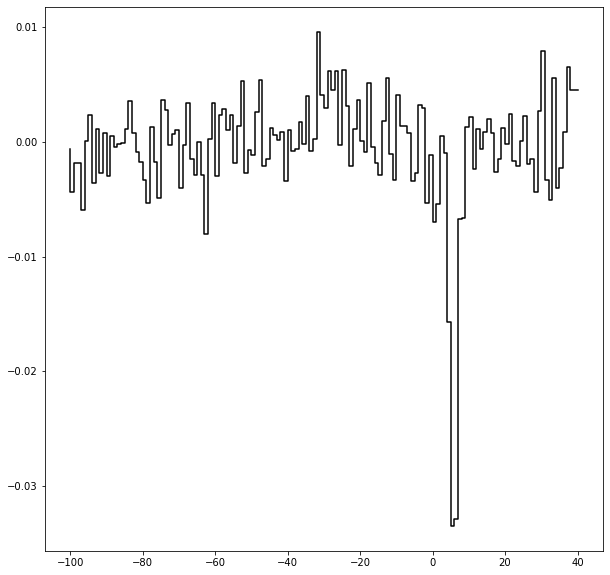

In [11]:
# Plot the data:
fig, ax1 = plt.subplots(1, figsize=(10, 10))

# Plot the xx:
ax1.step(vel67, (Ta67-np.median(Ta67))/np.median(Ta67), 'k', ms=3, label='OH 1667')
ax1.plot(vel67, y_pred67*u.K, color='b', ls='--', alpha=0.8)
#ax1.step(vel65, Ta65/np.mean(Ta67), 'g', label='OH 1665')
#ax1.step(vel12, Ta12/np.mean(Ta67)-0.01, 'r', label='OH 1612')
#ax1.step(vel20, Ta20/np.mean(Ta67), 'b', label='OH 1720')
ax1.set_title('18cm OH VLA, W51 LOS Cloud, 7 km/s, (e.g. Neufeld 2002)')
ax1.set_xlabel('VELO (km/s)')
ax1.set_ylabel(r'$\tau$')
ax1.legend()
#ax1.set_ylim([0.95, 1.05])
#ax1.set_xlim([-20, 20])
#ax1.axvline(7.2, color='k', ls='dashed')
fig.savefig('W51testGauss.png', format='png')

In [12]:
print('Amp is: ' + str(amp67))
print('Center is: ' + str(mean67))
print('Sigma is: ' + str(stddev67))
print('FWHM is ' + str(2.355*stddev67))

NameError: name 'amp67' is not defined

In [13]:
# what is dv?
dv = 0.5

# Choose velocity range to calculate sideband temp.
vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
igood = np.where((vel67 >= -100) & (vel67 <= 40))

# Reload Data:
vel67 = vel67[igood]
Ta67 = Ta67[igood]

Tc = np.median(Ta67)

# Choose velocity range to integrate.
vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
igood = np.where((vel67 >= 0) & (vel67 <= 15))

Ta67 = Ta67[igood]

print("EW (km/s) is: " + str(np.sum(((Ta67-Tc)/Tc)*dv)))

EW (km/s) is: -0.05298666302885696


In [2]:
# For W51 Sofia:
oh67s = ascii.read("ShallowClean/w51/w51-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=309)
oh65s = ascii.read("ShallowClean/w51/w51-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh12s = ascii.read("ShallowClean/w51/w51-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh20s = ascii.read("ShallowClean/w51/w51-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel67s = oh67s['VELO (km/s)']
Ta67s = oh67s['Ta (K)']
vel65s = oh65s['VELO (km/s)']
Ta65s = oh65s['Ta (K)']
vel12s = oh12s['VELO (km/s)']
Ta12s = oh12s['Ta (K)']
vel20s = oh20s['VELO (km/s)']
Ta20s = oh20s['Ta (K)']

# Choose velocity range.
igood = np.where((vel67s >= -10) & (vel67s <= 15))

# Get data ranges:
vel67s = vel67s[igood]
Ta67s = Ta67s[igood]
vel65s = vel65s[igood]
Ta65s = Ta65s[igood]
vel12s = vel12s[igood]
Ta12s = Ta12s[igood]
vel20s = vel20s[igood]
Ta20s = Ta20s[igood]

# For W51 1:
oh671 = ascii.read("ShallowClean/w51/w51-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=309)
oh651 = ascii.read("ShallowClean/w51/w51-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh121 = ascii.read("ShallowClean/w51/w51-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh201 = ascii.read("ShallowClean/w51/w51-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel671 = oh671['VELO (km/s)']
Ta671 = oh671['Ta (K)']
vel651 = oh651['VELO (km/s)']
Ta651 = oh651['Ta (K)']
vel121 = oh121['VELO (km/s)']
Ta121 = oh121['Ta (K)']
vel201 = oh201['VELO (km/s)']
Ta201 = oh201['Ta (K)']

# Choose velocity range.
igood = np.where((vel671 >= -10) & (vel671 <= 15))

# Get data ranges:
vel671 = vel671[igood]
Ta671 = Ta671[igood]
vel651 = vel651[igood]
Ta651 = Ta651[igood]
vel121 = vel121[igood]
Ta121 = Ta121[igood]
vel201 = vel201[igood]
Ta201 = Ta201[igood]

# For W51 2:
oh672 = ascii.read("ShallowClean/w51/w51-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=309)
oh652 = ascii.read("ShallowClean/w51/w51-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh122 = ascii.read("ShallowClean/w51/w51-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh202 = ascii.read("ShallowClean/w51/w51-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel672 = oh672['VELO (km/s)']
Ta672 = oh672['Ta (K)']
vel652 = oh652['VELO (km/s)']
Ta652 = oh652['Ta (K)']
vel122 = oh122['VELO (km/s)']
Ta122 = oh122['Ta (K)']
vel202 = oh202['VELO (km/s)']
Ta202 = oh202['Ta (K)']

# Choose velocity range.
igood = np.where((vel672 >= -10) & (vel672 <= 15))

# Get data ranges:
vel672 = vel672[igood]
Ta672 = Ta672[igood]
vel652 = vel652[igood]
Ta652 = Ta652[igood]
vel122 = vel122[igood]
Ta122 = Ta122[igood]
vel202 = vel202[igood]
Ta202 = Ta202[igood]

# For W51 2:
oh673 = ascii.read("ShallowClean/w51/w51-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=309)
oh653 = ascii.read("ShallowClean/w51/w51-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh123 = ascii.read("ShallowClean/w51/w51-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh203 = ascii.read("ShallowClean/w51/w51-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel673 = oh673['VELO (km/s)']
Ta673 = oh673['Ta (K)']
vel653 = oh653['VELO (km/s)']
Ta653 = oh653['Ta (K)']
vel123 = oh123['VELO (km/s)']
Ta123 = oh123['Ta (K)']
vel203 = oh203['VELO (km/s)']
Ta203 = oh203['Ta (K)']

# Choose velocity range.
igood = np.where((vel673 >= -10) & (vel673 <= 15))

# Get data ranges:
vel673 = vel673[igood]
Ta673 = Ta673[igood]
vel653 = vel653[igood]
Ta653 = Ta653[igood]
vel123 = vel123[igood]
Ta123 = Ta123[igood]
vel203 = vel203[igood]
Ta203 = Ta203[igood]


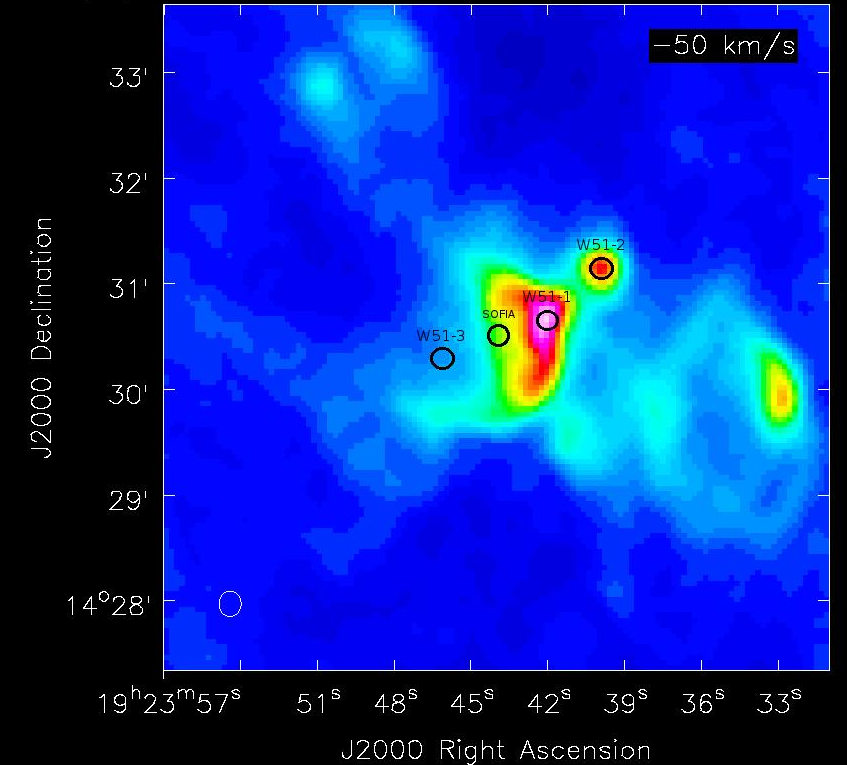

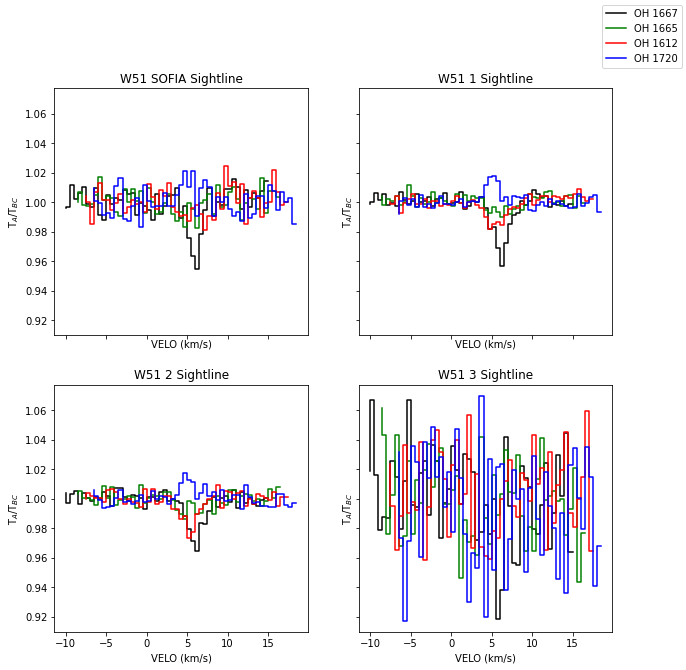

In [3]:
# Plot the data:
fig, axs = plt.subplots(2,2, figsize=(10, 10), sharey='all', sharex='all')

# Plot the xx:
axs[0,0].step(vel67s, Ta67s/np.median(Ta67s), 'k', label='OH 1667')
axs[0,0].step(vel65s, Ta65s/np.median(Ta65s), 'g', label='OH 1665')
axs[0,0].step(vel12s, Ta12s/np.median(Ta12s), 'r', label='OH 1612')
axs[0,0].step(vel20s, Ta20s/np.median(Ta20s), 'b', label='OH 1720')
axs[0,0].set_ylabel(r'T$_{A}$/T$_{BC}$')
axs[0,0].set_xlabel('VELO (km/s)')
axs[0,0].set_title('W51 SOFIA Sightline')

axs[0,1].step(vel671, Ta671/np.median(Ta671), 'k')
axs[0,1].step(vel651, Ta651/np.median(Ta651), 'g')
axs[0,1].step(vel121, Ta121/np.median(Ta121), 'r')
axs[0,1].step(vel201, Ta201/np.median(Ta201), 'b')
axs[0,1].set_ylabel(r'T$_{A}$/T$_{BC}$')
axs[0,1].set_xlabel('VELO (km/s)')
axs[0,1].set_title('W51 1 Sightline')

axs[1,0].step(vel672, Ta672/np.median(Ta672), 'k')
axs[1,0].step(vel652, Ta652/np.median(Ta652), 'g')
axs[1,0].step(vel122, Ta122/np.median(Ta122), 'r')
axs[1,0].step(vel202, Ta202/np.median(Ta202), 'b')
axs[1,0].set_ylabel(r'T$_{A}$/T$_{BC}$')
axs[1,0].set_xlabel('VELO (km/s)')
axs[1,0].set_title('W51 2 Sightline')

axs[1,1].step(vel673, Ta673/np.median(Ta673), 'k')
axs[1,1].step(vel653, Ta653/np.median(Ta653), 'g')
axs[1,1].step(vel123, Ta123/np.median(Ta123), 'r')
axs[1,1].step(vel203, Ta203/np.median(Ta203), 'b')
axs[1,1].set_ylabel(r'T$_{A}$/T$_{BC}$')
axs[1,1].set_xlabel('VELO (km/s)')
axs[1,1].set_title('W51 3 Sightline')


fig.legend()
#fig.savefig('W51Sightlines.png')

Image('ShallowClean/w51/W51.png')

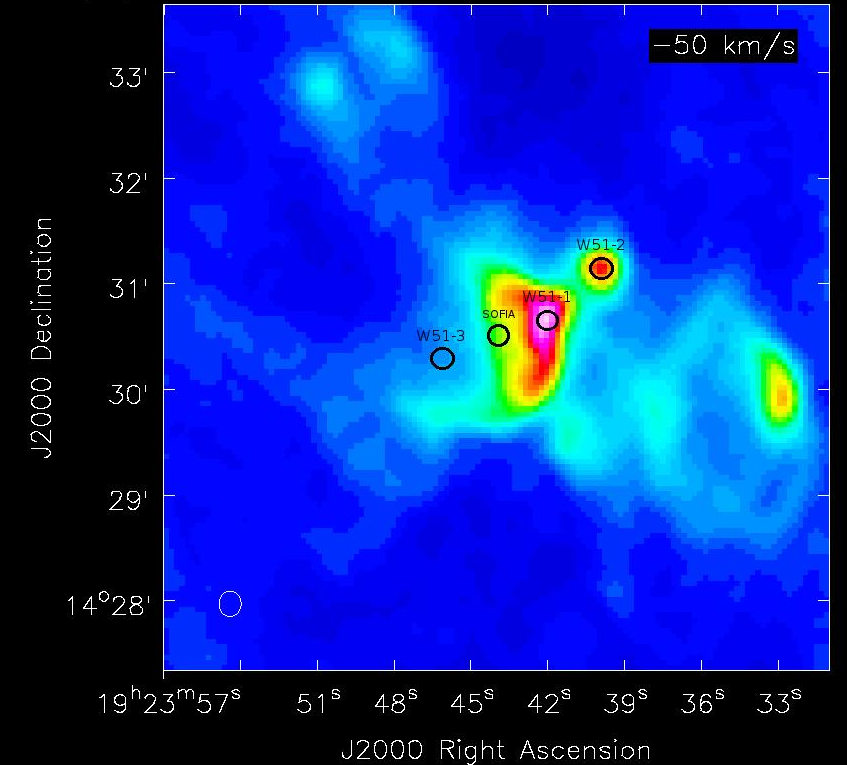

In [4]:
Image('ShallowClean/w51/W51.png')

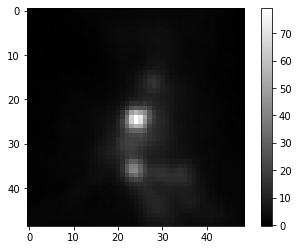

In [20]:
# Get ATLASGAL Image:
hdu = fits.open("ATLASGAL Cutouts/W51/W51_atlasgal.fits")
image_data = hdu[0].data
plt.imshow(image_data, cmap='gray')
plt.colorbar()

In [18]:
# Gauss fit, creating a Spec1D Object
spectrum = Spectrum1D(flux=(Ta67s-np.median(Ta67s))/np.median(Ta67s)*u.K,
                      spectral_axis=vel67s*u.km/u.s, velocity_convention='doppler_radio')

# Calculate uncertainty in spectra:
noise_region = SpectralRegion(-10*u.km/u.s, 0*u.km/u.s)
spectrum = noise_region_uncertainty(spectrum, noise_region)

# Estimate Gaussian Parameters:
sub_region = SpectralRegion(0*u.km/u.s, 10*u.km/u.s)
sub_spectrum = extract_region(spectrum, sub_region)

# First estimate of parameters of outer galaxy cloud
stddev67s = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).stddev[0]*u.km/u.s
mean67s = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).mean[0]*u.km/u.s
amp67s = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).amplitude[0]

# Gauss fit, creating a Spec1D Object
spectrum = Spectrum1D(flux=(Ta671-np.median(Ta671))/np.median(Ta671)*u.K,
                      spectral_axis=vel671*u.km/u.s, velocity_convention='doppler_radio')

# Calculate uncertainty in spectra:
noise_region = SpectralRegion(-10*u.km/u.s, 0*u.km/u.s)
spectrum = noise_region_uncertainty(spectrum, noise_region)

# Estimate Gaussian Parameters:
sub_region = SpectralRegion(0*u.km/u.s, 10*u.km/u.s)
sub_spectrum = extract_region(spectrum, sub_region)

# First estimate of parameters of outer galaxy cloud
stddev671 = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).stddev[0]*u.km/u.s
mean671 = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).mean[0]*u.km/u.s
amp671 = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).amplitude[0]

# Gauss fit, creating a Spec1D Object
spectrum = Spectrum1D(flux=(Ta672-np.median(Ta672))/np.median(Ta672)*u.K,
                      spectral_axis=vel672*u.km/u.s, velocity_convention='doppler_radio')

# Calculate uncertainty in spectra:
noise_region = SpectralRegion(-10*u.km/u.s, 0*u.km/u.s)
spectrum = noise_region_uncertainty(spectrum, noise_region)

# Estimate Gaussian Parameters:
sub_region = SpectralRegion(0*u.km/u.s, 10*u.km/u.s)
sub_spectrum = extract_region(spectrum, sub_region)

# First estimate of parameters of outer galaxy cloud
stddev672 = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).stddev[0]*u.km/u.s
mean672 = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).mean[0]*u.km/u.s
amp672 = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).amplitude[0]

# Gauss fit, creating a Spec1D Object
spectrum = Spectrum1D(flux=(Ta673-np.median(Ta673))/np.median(Ta673)*u.K,
                      spectral_axis=vel673*u.km/u.s, velocity_convention='doppler_radio')

# Calculate uncertainty in spectra:
noise_region = SpectralRegion(-10*u.km/u.s, 0*u.km/u.s)
spectrum = noise_region_uncertainty(spectrum, noise_region)

# Estimate Gaussian Parameters:
sub_region = SpectralRegion(0*u.km/u.s, 10*u.km/u.s)
sub_spectrum = extract_region(spectrum, sub_region)

# First estimate of parameters of outer galaxy cloud
stddev673 = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).stddev[0]*u.km/u.s
mean673 = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).mean[0]*u.km/u.s
amp673 = estimate_line_parameters(sub_spectrum, models.Gaussian1D()).amplitude[0]

ValueError: Bound -10.0 km / s, could not be converted to pixel index using spectrum's WCS. Exception: doppler_rest not set, cannot convert to/from velocities

In [ ]:
print(stddev67s)
print(stddev671)
print(stddev672)
print(stddev673)

In [ ]:
print(amp67s)
print(amp671)
print(amp672)
print(amp673)

In [ ]:
print(mean67s)
print(mean671)
print(mean672)
print(mean673)

In [ ]:
# Choose velocity range to calculate sideband temp.
vel67s = oh67s['VELO (km/s)']
Ta67s = oh67s['Ta (K)']
igood = np.where((vel67s >= -50) & (vel67s <= -5))

# Reload Data:
vel67s = vel67s[igood]
Ta67s = Ta67s[igood]

Tc = np.median(Ta67s)
print(Tc)

# Choose velocity range to integrate.
vel67s = oh67s['VELO (km/s)']
Ta67s = oh67s['Ta (K)']
dv = np.abs(vel67s[0] - vel67s[1])
igood = np.where((vel67s >= 0) & (vel67s <= 15))

Ta67s = Ta67s[igood]
EW = np.sum(((Ta67s-Tc)/Tc)*dv)

print("EW (km/s) is: " + str(EW))

In [ ]:
# Choose velocity range to calculate sideband temp.
vel67s = oh67s['VELO (km/s)']
Ta67s = oh67s['Ta (K)']
igood = np.where((vel67s >= -10) & (vel67s <= 0))

# Reload Data:
vel67s = vel67s[igood]
Ta67s = Ta67s[igood]
Tc = np.median(Ta67s)

sigma = np.std(Ta67s)
sigma

In [ ]:
# Noise in EW
((sigma-Tc)/Tc)*dv

In [ ]:
# Noise in tau
(sigma - Tc) / Tc

In [ ]:
### What is the column density?

k = 1 # 1 for 1667, 5/9 for 1665, 1/9 for 1612 and 1720.
Tex = 5
NOH = (EW * Tex)/ (0.45 * k)
NOH # 10-14
#9.7e13

In [ ]:
# What is the max optical depth:
np.min((Ta67s-Tc)/(Tc))

In [ ]:
# For W51 Sofia:
oh67s = ascii.read("ShallowClean/w51/w51-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=309)
oh65s = ascii.read("ShallowClean/w51/w51-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh12s = ascii.read("ShallowClean/w51/w51-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh20s = ascii.read("ShallowClean/w51/w51-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel67s = oh67s['VELO (km/s)']
Ta67s = oh67s['Ta (K)']
vel65s = oh65s['VELO (km/s)']
Ta65s = oh65s['Ta (K)']
vel12s = oh12s['VELO (km/s)']
Ta12s = oh12s['Ta (K)']
vel20s = oh20s['VELO (km/s)']
Ta20s = oh20s['Ta (K)']

# Choose velocity range.
igood = np.where((vel67s >= -10) & (vel67s <= 15))

# Get data ranges:
vel67s = vel67s[igood]
Ta67s = Ta67s[igood]
vel65s = vel65s[igood]
Ta65s = Ta65s[igood]
vel12s = vel12s[igood]
Ta12s = Ta12s[igood]
vel20s = vel20s[igood]
Ta20s = Ta20s[igood]

# For W51 1:
oh671 = ascii.read("ShallowClean/w51/w51-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=309)
oh651 = ascii.read("ShallowClean/w51/w51-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh121 = ascii.read("ShallowClean/w51/w51-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh201 = ascii.read("ShallowClean/w51/w51-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel671 = oh671['VELO (km/s)']
Ta671 = oh671['Ta (K)']
vel651 = oh651['VELO (km/s)']
Ta651 = oh651['Ta (K)']
vel121 = oh121['VELO (km/s)']
Ta121 = oh121['Ta (K)']
vel201 = oh201['VELO (km/s)']
Ta201 = oh201['Ta (K)']

# Choose velocity range.
igood = np.where((vel671 >= -10) & (vel671 <= 15))

# Get data ranges:
vel671 = vel671[igood]
Ta671 = Ta671[igood]
vel651 = vel651[igood]
Ta651 = Ta651[igood]
vel121 = vel121[igood]
Ta121 = Ta121[igood]
vel201 = vel201[igood]
Ta201 = Ta201[igood]

# For W51 2:
oh672 = ascii.read("ShallowClean/w51/w51-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=309)
oh652 = ascii.read("ShallowClean/w51/w51-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh122 = ascii.read("ShallowClean/w51/w51-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh202 = ascii.read("ShallowClean/w51/w51-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel672 = oh672['VELO (km/s)']
Ta672 = oh672['Ta (K)']
vel652 = oh652['VELO (km/s)']
Ta652 = oh652['Ta (K)']
vel122 = oh122['VELO (km/s)']
Ta122 = oh122['Ta (K)']
vel202 = oh202['VELO (km/s)']
Ta202 = oh202['Ta (K)']

# Choose velocity range.
igood = np.where((vel672 >= -10) & (vel672 <= 15))

# Get data ranges:
vel672 = vel672[igood]
Ta672 = Ta672[igood]
vel652 = vel652[igood]
Ta652 = Ta652[igood]
vel122 = vel122[igood]
Ta122 = Ta122[igood]
vel202 = vel202[igood]
Ta202 = Ta202[igood]

# For W51 2:
oh673 = ascii.read("ShallowClean/w51/w51-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=309)
oh653 = ascii.read("ShallowClean/w51/w51-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh123 = ascii.read("ShallowClean/w51/w51-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh203 = ascii.read("ShallowClean/w51/w51-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel673 = oh673['VELO (km/s)']
Ta673 = oh673['Ta (K)']
vel653 = oh653['VELO (km/s)']
Ta653 = oh653['Ta (K)']
vel123 = oh123['VELO (km/s)']
Ta123 = oh123['Ta (K)']
vel203 = oh203['VELO (km/s)']
Ta203 = oh203['Ta (K)']

# Choose velocity range.
igood = np.where((vel673 >= -30) & (vel673 <= 20))

# Get data ranges:
vel673 = vel673[igood]
Ta673 = Ta673[igood]
vel653 = vel653[igood]
Ta653 = Ta653[igood]
vel123 = vel123[igood]
Ta123 = Ta123[igood]
vel203 = vel203[igood]
Ta203 = Ta203[igood]

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(10, 10), sharey='all', sharex='all')

# Plot the xx:
axs.step(vel671, (Ta671-np.median(Ta671))/np.median(Ta671), 'k', label='OH 1667')
axs.step(vel651, (Ta651-np.median(Ta651))/np.median(Ta651), 'g', label='OH 1665')
axs.step(vel121, (Ta121-np.median(Ta121))/np.median(Ta121), 'r', label='OH 1612')
axs.step(vel201, (Ta201-np.median(Ta201))/np.median(Ta201), 'b', label='OH 1720')
axs.set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs.set_xlabel('VELO (km/s)')
axs.set_title('W51 SOFIA Sightline')

fig.legend()
#fig.savefig('W51Sightlines_opticaldepth.png')
#fig.savefig('W51Sightlines_comparative.png')

#Image('ShallowClean/w51/W51.png')
#EW = np.sum(((Ta67s-Tc)/Tc)*dv)

In [ ]:
# Choose velocity range.
igood67 = np.where((vel67s >= 0) & (vel67s<= 10))
igood65 = np.where((vel65s >= 0) & (vel65s<= 10))
igood12 = np.where((vel12s >= 0) & (vel12s<= 10))
igood20 = np.where((vel20s >= 0) & (vel20s<= 10))

# Choose a continuum.
igood67c = np.where((vel67s >= -10) & (vel67s <= 0))
igood65c = np.where((vel65s >= -10) & (vel65s <= 0))
igood12c = np.where((vel12s >= -10) & (vel12s <= 0))
igood20c = np.where((vel20s >= -10) & (vel20s <= 0))

peak67 = np.max(np.abs((Ta67s[igood67]-np.median(Ta67s[igood67c]))/np.median(Ta67s[igood67c])))
peak65 = np.max(np.abs((Ta65s[igood65]-np.median(Ta65s[igood65c]))/np.median(Ta65s[igood65c])))
peak12 = np.max(np.abs((Ta12s[igood12]-np.median(Ta12s[igood12c]))/np.median(Ta12s[igood12c])))
peak20 = np.max(np.abs((Ta20s[igood20]-np.median(Ta20s[igood20c]))/np.median(Ta20s[igood20c])))

print(peak67)
print(peak65)
print(peak12)
print(peak20)
print("err is +/- 0.001")

In [ ]:
# GaussianFit
gaussFit671 = models.Gaussian1D(amplitude=-0.01, mean=6*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit671 = fit(gaussFit671, vel671*u.km/u.s, (Ta671-np.median(Ta671[igood67c]))/np.median(Ta671[igood67c])*u.K)

#Predict the y values:
y_pred671 = y_fit671(vel671*u.km/u.s)

# parameters:
amp671 = y_fit671.amplitude[0]*u.K
mean671 = y_fit671.mean[0]*u.km/u.s
stddev671 = y_fit671.stddev[0]*u.km/u.s

# GaussianFit
gaussFit651 = models.Gaussian1D(amplitude=-0.01, mean=6*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit651 = fit(gaussFit651, vel651*u.km/u.s, (Ta651-np.median(Ta651[igood65c]))/np.median(Ta651[igood65c])*u.K)

#Predict the y values:
y_pred651 = y_fit651(vel651*u.km/u.s)

# parameters:
amp651 = y_fit651.amplitude[0]*u.K
mean651 = y_fit651.mean[0]*u.km/u.s
stddev651 = y_fit651.stddev[0]*u.km/u.s

# GaussianFit
gaussFit201 = models.Gaussian1D(amplitude=0.01, mean=6*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit201 = fit(gaussFit201, vel201*u.km/u.s, (Ta201-np.median(Ta201[igood20c]))/np.median(Ta201[igood20c])*u.K)

#Predict the y values:
y_pred201 = y_fit201(vel201*u.km/u.s)

# parameters:
amp201 = y_fit201.amplitude[0]*u.K
mean201 = y_fit201.mean[0]*u.km/u.s
stddev201 = y_fit201.stddev[0]*u.km/u.s

# GaussianFit
gaussFit121 = models.Gaussian1D(amplitude=-0.01, mean=6*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit121 = fit(gaussFit121, vel121*u.km/u.s, (Ta121-np.median(Ta121[igood12c]))/np.median(Ta121[igood12c])*u.K)

#Predict the y values:
y_pred121 = y_fit121(vel12s*u.km/u.s)

# parameters:
amp121 = y_fit121.amplitude[0]*u.K
mean121 = y_fit121.mean[0]*u.km/u.s
stddev121 = y_fit121.stddev[0]*u.km/u.s

In [ ]:
# Attempt to loading the SOFIA data:
ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Choose velocity range.
igood = np.where((VelSof >= -20) & (VelSof <= 30))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

In [ ]:
# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof-10.1)/10.1, 'k', label='OH 2.5 THz')
axs[0].axvline(6, ls='dashed', color='r', alpha=0.8)
axs[0].legend(loc='best')

axs[1].step(vel671, (Ta671-np.median(Ta671))/np.median(Ta671), 'k', label='OH 1667 MHz')
axs[1].plot(vel671, y_pred671, color='r', ls='--', alpha=0.8)
axs[1].axhline(0, color='k', ls='dashed')
axs[1].legend(loc='best')

axs[2].step(vel651, (Ta651-np.median(Ta651))/np.median(Ta651), 'k', label='OH 1665 MHz')
axs[2].plot(vel651, y_pred651*u.K, color='r', ls='--', alpha=0.8)
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].legend(loc='best')

axs[3].step(vel121, (Ta121-np.median(Ta121))/np.median(Ta121), 'k', label='OH 1612 MHz')
axs[3].plot(vel121, y_pred121*u.K, color='r', ls='--', alpha=0.8)
axs[3].axhline(0, color='k', ls='dashed')
axs[3].legend(loc='best')

axs[4].step(vel201, (Ta201-np.median(Ta201))/np.median(Ta201), 'k', label='OH 1720 MHz')
axs[4].plot(vel201, y_pred201*u.K, color='r', ls='--', alpha=0.8)
axs[4].axhline(0, color='k', ls='dashed')
axs[4].legend(loc='best')

plt.xlabel('Velocity (km/s)')
axs[0].set_title('W51')

fig.savefig('W51_fitted.png')

#Image('ShallowClean/w51/W51.png')

In [ ]:
print("W51 LOS Cloud")
print("Line -- Amp -- Center Velocity -- FWHM")
print("1720 " + str.format('{0:.3f}', amp201.value) + ' ' 
      + str.format('{0:.3f}',mean201.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev201.value))
print("1667 " + str.format('{0:.3f}', amp671.value) + ' ' 
      + str.format('{0:.3f}',mean671.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev671.value))
print("1665 " + str.format('{0:.3f}', amp651.value) + ' ' 
      + str.format('{0:.3f}',mean651.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev651.value))
print("1612 " + str.format('{0:.3f}', amp121.value) + ' ' 
      + str.format('{0:.3f}',mean121.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev121.value))

In [35]:
vel67 = oh671['VELO (km/s)']
Ta67 = oh671['Ta (K)']

EWfunc(Ta67, vel67, 6.4, 2.1, 0.5)

(-0.09039972885134309,
 6564.9543457029995,
 0.010699690350505083,
 70.2429786642248)

In [36]:
# Solving directing for Tex
(1*0.45)/0.090

5.0

In [37]:
EWfunc(Ta651, vel651, 6.6, 3.1, 0.5)

(-0.02576411116783018,
 6269.906738281,
 0.004401812752213621,
 27.598955435755418)

In [38]:
(1*0.45*(1/5))/0.0257

3.5019455252918292

In [39]:
EWfunc(Ta121, vel121, 5.7, 2.4, 0.5)

(-0.0475579859852183, 6584.000976562, 0.005654236292182519, 37.227497269442004)

In [40]:
(1*0.45*(1/9))/0.048

1.0416666666666665

In [41]:
EWfunc(Ta201, vel201, 5.2, 1.7, 0.5)

(0.032738475202741986,
 6555.391601562,
 0.005272533275944264,
 34.563520356081206)

In [42]:
(1*0.45*(1/9))/-0.033

-1.515151515151515

### Now let's show the W3 IRS5 image and VLA spectra:

In [8]:
# For W3 IRS5 Sofia:
oh67s = ascii.read("ShallowClean/w3irs5/w3irs5-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=808)
oh65s = ascii.read("ShallowClean/w3irs5/w3irs5-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=811, data_end=1610)
oh12s = ascii.read("ShallowClean/w3irs5/w3irs5-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=1613, data_end=2412)
oh20s = ascii.read("ShallowClean/w3irs5/w3irs5-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=2415, data_end=3214)

vel67s = oh67s['VELO (km/s)']
Ta67s = oh67s['Ta (K)']
vel65s = oh65s['VELO (km/s)']
Ta65s = oh65s['Ta (K)']
vel12s = oh12s['VELO (km/s)']
Ta12s = oh12s['Ta (K)']
vel20s = oh20s['VELO (km/s)']
Ta20s = oh20s['Ta (K)']

# Choose velocity range.
igood = np.where((vel67s >= -30) & (vel67s <= -10))

# Get data ranges:
vel67s = vel67s[igood]
Ta67s = Ta67s[igood]
vel65s = vel65s[igood]
Ta65s = Ta65s[igood]
vel12s = vel12s[igood]
Ta12s = Ta12s[igood]
vel20s = vel20s[igood]
Ta20s = Ta20s[igood]

# For W3 IRS5 1:
oh671 = ascii.read("ShallowClean/w3irs5/w3irs5-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=808)
oh651 = ascii.read("ShallowClean/w3irs5/w3irs5-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=811, data_end=1610)
oh121 = ascii.read("ShallowClean/w3irs5/w3irs5-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=1613, data_end=2412)
oh201 = ascii.read("ShallowClean/w3irs5/w3irs5-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=2415, data_end=3214)

vel671 = oh671['VELO (km/s)']
Ta671 = oh671['Ta (K)']
vel651 = oh651['VELO (km/s)']
Ta651 = oh651['Ta (K)']
vel121 = oh121['VELO (km/s)']
Ta121 = oh121['Ta (K)']
vel201 = oh201['VELO (km/s)']
Ta201 = oh201['Ta (K)']

# Choose velocity range.
igood = np.where((vel671 >= -30) & (vel671 <= -10))

# Get data ranges:
vel671 = vel671[igood]
Ta671 = Ta671[igood]
vel651 = vel651[igood]
Ta651 = Ta651[igood]
vel121 = vel121[igood]
Ta121 = Ta121[igood]
vel201 = vel201[igood]
Ta201 = Ta201[igood]

# For W3 IRS5 2:
oh672 = ascii.read("ShallowClean/w3irs5/w3irs5-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=808)
oh652 = ascii.read("ShallowClean/w3irs5/w3irs5-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=811, data_end=1610)
oh122 = ascii.read("ShallowClean/w3irs5/w3irs5-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=1613, data_end=2412)
oh202 = ascii.read("ShallowClean/w3irs5/w3irs5-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=2415, data_end=3214)

vel672 = oh672['VELO (km/s)']
Ta672 = oh672['Ta (K)']
vel652 = oh652['VELO (km/s)']
Ta652 = oh652['Ta (K)']
vel122 = oh122['VELO (km/s)']
Ta122 = oh122['Ta (K)']
vel202 = oh202['VELO (km/s)']
Ta202 = oh202['Ta (K)']

# Choose velocity range.
igood = np.where((vel672 >= -30) & (vel672 <= -10))

# Get data ranges:
vel672 = vel672[igood]
Ta672 = Ta672[igood]
vel652 = vel652[igood]
Ta652 = Ta652[igood]
vel122 = vel122[igood]
Ta122 = Ta122[igood]

vel202 = vel202[igood]
Ta202 = Ta202[igood]

# For W3 IRS5 3:
oh673 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=808)
oh653 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=811, data_end=1610)
oh123 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=1613, data_end=2412)
oh203 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=2415, data_end=3214)


vel673 = oh673['VELO (km/s)']
Ta673 = oh673['Ta (K)']
vel653 = oh653['VELO (km/s)']
Ta653 = oh653['Ta (K)']
vel123 = oh123['VELO (km/s)']
Ta123 = oh123['Ta (K)']
vel203 = oh203['VELO (km/s)']
Ta203 = oh203['Ta (K)']

# Choose velocity range.
igood = np.where((vel673 >= -30) & (vel673 <= -10))

# Get data ranges:
vel673 = vel673[igood]
Ta673 = Ta673[igood]
vel653 = vel653[igood]
Ta653 = Ta653[igood]
vel123 = vel123[igood]
Ta123 = Ta123[igood]
vel203 = vel203[igood]
Ta203 = Ta203[igood]

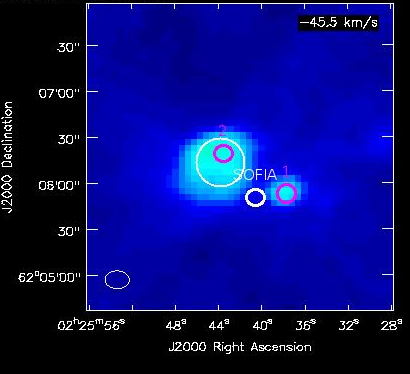

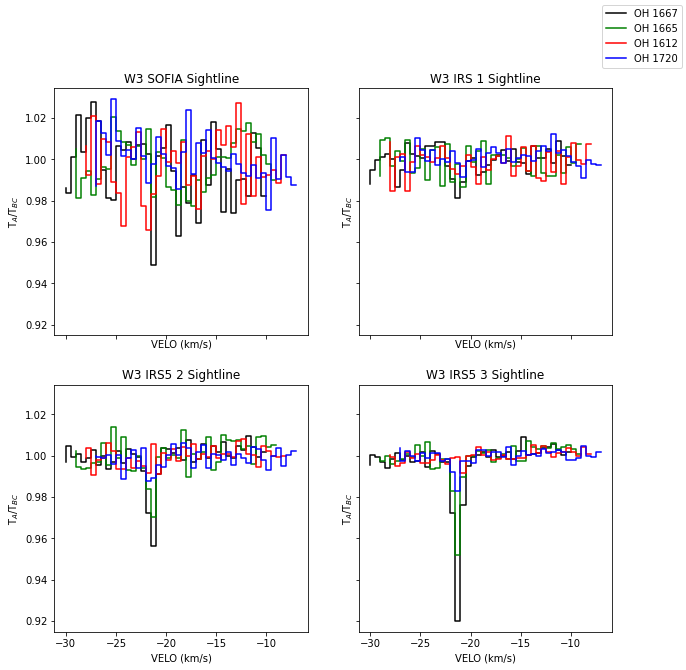

In [9]:
# Plot the data:
fig, axs = plt.subplots(2,2, figsize=(10, 10), sharey='all', sharex='all')

# Plot the xx:
axs[0,0].step(vel67s, Ta67s/np.median(Ta67s), 'k', label='OH 1667')
axs[0,0].step(vel65s, Ta65s/np.median(Ta65s), 'g', label='OH 1665')
axs[0,0].step(vel12s, Ta12s/np.median(Ta12s), 'r', label='OH 1612')
axs[0,0].step(vel20s, Ta20s/np.median(Ta20s), 'b', label='OH 1720')
axs[0,0].set_ylabel(r'T$_{A}$/T$_{BC}$')
axs[0,0].set_xlabel('VELO (km/s)')
axs[0,0].set_title('W3 SOFIA Sightline')

axs[0,1].step(vel671, Ta671/np.median(Ta671), 'k')
axs[0,1].step(vel651, Ta651/np.median(Ta651), 'g')
axs[0,1].step(vel121, Ta121/np.median(Ta121), 'r')
axs[0,1].step(vel201, Ta201/np.median(Ta201), 'b')
axs[0,1].set_ylabel(r'T$_{A}$/T$_{BC}$')
axs[0,1].set_xlabel('VELO (km/s)')
axs[0,1].set_title('W3 IRS 1 Sightline')

axs[1,0].step(vel672, Ta672/np.median(Ta672), 'k')
axs[1,0].step(vel652, Ta652/np.median(Ta652), 'g')
axs[1,0].step(vel122, Ta122/np.median(Ta122), 'r')
axs[1,0].step(vel202, Ta202/np.median(Ta202), 'b')
axs[1,0].set_ylabel(r'T$_{A}$/T$_{BC}$')
axs[1,0].set_xlabel('VELO (km/s)')
axs[1,0].set_title('W3 IRS5 2 Sightline')

axs[1,1].step(vel673, Ta673/np.median(Ta673), 'k')
axs[1,1].step(vel653, Ta653/np.median(Ta653), 'g')
axs[1,1].step(vel123, Ta123/np.median(Ta123), 'r')
axs[1,1].step(vel203, Ta203/np.median(Ta203), 'b')
axs[1,1].set_ylabel(r'T$_{A}$/T$_{BC}$')
axs[1,1].set_xlabel('VELO (km/s)')
axs[1,1].set_title('W3 IRS5 3 Sightline')

fig.legend()
fig.savefig('W3IRS5Sightlines.png')

Image('ShallowClean/w3irs5/w3irs5.png')

In [ ]:
# what is dv?
dv = 0.5

# Choose velocity range to calculate sideband temp.
vel67 = oh67s['VELO (km/s)']
Ta67 = oh67s['Ta (K)']
igood = np.where((vel67 >= -100) & (vel67 <= 40))

# Reload Data:
vel67 = vel67[igood]
Ta67 = Ta67[igood]

Tc = np.median(Ta67)
sigma = sigma = np.std((Ta67s - Tc)/Tc)

# Choose velocity range to integrate.
vel67 = oh67s['VELO (km/s)']
Ta67 = oh67s['Ta (K)']
igood = np.where((vel67 >= -23) & (vel67 <= -20.5))

Ta67 = Ta67[igood]
EW = np.sum(((Ta67-Tc)/Tc)*dv)

print("EW (km/s) is: " + str(np.sum(((Ta67-Tc)/Tc)*dv)))
print("EW (km/s) err is: " + str(sigma))

In [ ]:
### What is the column density?

k = 1 # 1 for 1667, 5/9 for 1665, 1/9 for 1612 and 1720.
Tex = 5
NOH = (EW * Tex)/ (0.45 * k)
NOH # 10-14
#0.38e13

In [ ]:
#Ta67s = Ta673
#vel67s = vel673
#Ta65s = Ta653
#vel65s = vel653
#Ta12s = Ta123
#vel12s = vel123
#Ta20s = Ta203
#vel20s = vel203

# Choose velocity range.
igood67 = np.where((vel67s >= -23) & (vel67s<= -20.5))
igood65 = np.where((vel65s >= -23) & (vel65s<= -20.5))
igood12 = np.where((vel12s >= -23) & (vel12s<= -20.5))
igood20 = np.where((vel20s >= -23) & (vel20s<= -20.5))

# Choose a continuum.
igood67c = np.where((vel67s >= -100) & (vel67s <= 40))
igood65c = np.where((vel65s >= -100) & (vel65s <= 40))
igood12c = np.where((vel12s >= -100) & (vel12s <= 40))
igood20c = np.where((vel20s >= -100) & (vel20s <= 40))

peak67 = np.max(np.abs((Ta67s[igood67]-np.median(Ta67s[igood67c]))/np.median(Ta67s[igood67c])))
peak65 = np.max(np.abs((Ta65s[igood65]-np.median(Ta65s[igood65c]))/np.median(Ta65s[igood65c])))
peak12 = np.max(np.abs((Ta12s[igood12]-np.median(Ta12s[igood12c]))/np.median(Ta12s[igood12c])))
peak20 = np.max(np.abs((Ta20s[igood20]-np.median(Ta20s[igood20c]))/np.median(Ta20s[igood20c])))

print(peak67)
print(peak65)
print(peak12)
print(peak20)
print("err is +/- 0.001")

In [ ]:
#Ta67s = Ta673
#vel67s = vel673
#Ta65s = Ta653
#vel65s = vel653
#Ta12s = Ta123
#vel12s = vel123
#Ta20s = Ta203
#vel20s = vel203

# GaussianFit
gaussFit673 = models.Gaussian1D(amplitude=-0.05, mean=-22*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit673 = fit(gaussFit673, vel67s*u.km/u.s, (Ta673-np.median(Ta673[igood67c]))/np.median(Ta673[igood67c])*u.K)

#Predict the y values:
y_pred673 = y_fit673(vel673*u.km/u.s)

# parameters:
amp673 = y_fit673.amplitude[0]*u.K
mean673 = y_fit673.mean[0]*u.km/u.s
stddev673 = y_fit673.stddev[0]*u.km/u.s

# GaussianFit
gaussFit653 = models.Gaussian1D(amplitude=-0.01, mean=-22*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit653 = fit(gaussFit653, vel653*u.km/u.s, (Ta653-np.median(Ta653[igood65c]))/np.median(Ta653[igood65c])*u.K)

#Predict the y values:
y_pred653 = y_fit653(vel653*u.km/u.s)

# parameters:
amp65s = y_fit653.amplitude[0]*u.K
mean65s = y_fit653.mean[0]*u.km/u.s
stddev65s = y_fit653.stddev[0]*u.km/u.s

# GaussianFit
gaussFit203 = models.Gaussian1D(amplitude=0.01, mean=-22*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit203 = fit(gaussFit203, vel203*u.km/u.s, (Ta203-np.median(Ta203[igood20c]))/np.median(Ta203[igood20c])*u.K)

#Predict the y values:
y_pred203 = y_fit203(vel203*u.km/u.s)

# parameters:
amp203 = y_fit203.amplitude[0]*u.K
mean203 = y_fit203.mean[0]*u.km/u.s
stddev203 = y_fit203.stddev[0]*u.km/u.s

# GaussianFit
gaussFit123 = models.Gaussian1D(amplitude=-0.01, mean=-21*u.km/u.s, stddev=0.5*u.km/u.s)

# 2nd Fit:
y_fit123 = fit(gaussFit123, vel123*u.km/u.s, (Ta123-np.median(Ta123[igood12c]))/np.median(Ta123[igood12c])*u.K)

#Predict the y values:
y_pred123 = y_fit123(vel123*u.km/u.s)

# parameters:
amp123 = y_fit123.amplitude[0]*u.K
mean123 = y_fit123.mean[0]*u.km/u.s
stddev123 = y_fit123.stddev[0]*u.km/u.s

In [ ]:
#Ta67s = Ta673
#vel67s = vel673
#Ta65s = Ta653
#vel65s = vel653
#Ta12s = Ta123
#vel12s = vel123
#Ta20s = Ta203
#vel20s = vel203

# Plot the data:
fig, axs = plt.subplots(1, figsize=(10, 10), sharey='all', sharex='all')

# Plot the xx:
axs.step(vel673, (Ta673-np.median(Ta673))/np.median(Ta673), 'k', label='OH 1667')
#axs.plot(vel673, y_pred673, color='k', ls='--', alpha=0.8)

axs.step(vel653, (Ta653-np.median(Ta653))/np.median(Ta653)+0.04, 'g', label='OH 1665')
#axs.plot(vel653, y_pred653+0.1*u.K, color='g', ls='--', alpha=0.8)

axs.step(vel123, (Ta123-np.median(Ta123))/np.median(Ta123)+0.06, 'r', label='OH 1612')
#axs.plot(vel123, y_pred12s+0.2*u.K, color='r', ls='--', alpha=0.8)

axs.step(vel203, (Ta203-np.median(Ta203))/np.median(Ta203)+0.08, 'b', label='OH 1720')
#axs.plot(vel203, y_pred203+0.3*u.K, color='b', ls='--', alpha=0.8)

axs.set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs.set_xlabel('VELO (km/s)')
axs.set_title('W3 IRS5 Sightline 3')

fig.legend()
fig.savefig('W3IRS5SofiaSightlines_comparitive.png')

Image('ShallowClean/w3irs5/w3irs5.png')

In [ ]:
print("W3 IRS5 LOS Cloud")
print("Line -- Amp -- Center Velocity -- FWHM")
print("1720 " + str.format('{0:.3f}', amp20s.value) + ' ' 
      + str.format('{0:.3f}',mean20s.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev20s.value))
print("1667 " + str.format('{0:.3f}', amp67s.value) + ' ' 
      + str.format('{0:.3f}',mean67s.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev67s.value))
print("1665 " + str.format('{0:.3f}', amp65s.value) + ' ' 
      + str.format('{0:.3f}',mean65s.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev65s.value))
print("1612 " + str.format('{0:.3f}', amp12s.value) + ' ' 
      + str.format('{0:.3f}',mean12s.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev12s.value))

In [ ]:
# Attempt to loading the SOFIA data:
ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W3IRS5_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Choose velocity range.
igood = np.where((VelSof >= -30) & (VelSof <= -5))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

In [ ]:
# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof-7.8)/7.8, 'k', label='OH 2.5 THz')
axs[0].axvline(-21, ls='dashed', color='r', alpha=0.8)
axs[0].legend(loc='best')

axs[1].step(vel673, (Ta673-np.median(Ta673))/np.median(Ta673), 'k', label='OH 1667')
axs[1].plot(vel673, y_pred673, color='r', ls='--', alpha=0.8)
axs[1].axhline(0, color='k', ls='dashed')
axs[1].legend()

axs[2].step(vel653, (Ta653-np.median(Ta653))/np.median(Ta653), 'k', label='OH 1665')
axs[2].plot(vel653, y_pred653*u.K, color='r', ls='--', alpha=0.8)
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].legend()

axs[3].step(vel123, (Ta123-np.median(Ta123))/np.median(Ta123), 'k', label='OH 1612')
axs[3].plot(vel123, y_pred123*u.K, color='r', ls='--', alpha=0.8)
axs[3].axhline(0, color='k', ls='dashed')
axs[3].legend()

axs[4].step(vel203, (Ta203-np.median(Ta203))/np.median(Ta203), 'k', label='OH 1720')
axs[4].plot(vel203, y_pred203*u.K, color='r', ls='--', alpha=0.8)
axs[4].axhline(0, color='k', ls='dashed')
axs[4].legend(loc='lower left')

plt.xlabel('Velocity (km/s)')
axs[0].set_title('W3 IRS5')

fig.savefig('W3IRS5_fitted.png')

#Image('ShallowClean/w51/W51.png')

In [ ]:
print("W3 IRS5 LOS Cloud")
print("Line -- Amp -- Center Velocity -- FWHM")
print("1720 " + str.format('{0:.3f}', amp20s.value) + ' ' 
      + str.format('{0:.3f}',mean20s.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev20s.value))
print("1667 " + str.format('{0:.3f}', amp67s.value) + ' ' 
      + str.format('{0:.3f}',mean67s.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev67s.value))
print("1665 " + str.format('{0:.3f}', amp65s.value) + ' ' 
      + str.format('{0:.3f}',mean65s.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev65s.value))
print("1612 " + str.format('{0:.3f}', amp12s.value) + ' ' 
      + str.format('{0:.3f}',mean12s.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev12s.value))

In [ ]:
EWfunc(Ta673, vel673, -21, 2, 0.5)

In [ ]:
# Solving directing for Tex
(0.75*0.45*1)/0.071

In [ ]:
EWfunc(Ta653, vel653, -21, 2, 0.5)

In [ ]:
# Solving directing for Tex
(0.75*0.45*(1/5))/0.041

In [ ]:
EWfunc(Ta123, vel123, -21, 2, 0.5)

In [ ]:
# Solving directing for Tex
(0.75*0.45*(1/9))/0.0054

In [ ]:
EWfunc(Ta203, vel203, -21, 2, 0.5)

In [ ]:
# Solving directing for Tex
(0.75*0.45*(1/9))/0.017

### Let's now image and plot the spectrum of G43...

In [6]:
# For W3 IRS5 Sofia:
oh67s = ascii.read("ShallowClean/G34/G34-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=308)
oh65s = ascii.read("ShallowClean/G34/G34-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh12s = ascii.read("ShallowClean/G34/G34-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh20s = ascii.read("ShallowClean/G34/G34-sofia.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel67s = oh67s['VELO (km/s)']
Ta67s = oh67s['Ta (K)']
vel65s = oh65s['VELO (km/s)']
Ta65s = oh65s['Ta (K)']
vel12s = oh12s['VELO (km/s)']
Ta12s = oh12s['Ta (K)']
vel20s = oh20s['VELO (km/s)']
Ta20s = oh20s['Ta (K)']

# Choose velocity range.
igood = np.where((vel67s >= -10) & (vel67s <= 35))

# Get data ranges:
vel67s = vel67s[igood]
Ta67s = Ta67s[igood]
vel65s = vel65s[igood]
Ta65s = Ta65s[igood]
vel12s = vel12s[igood]
Ta12s = Ta12s[igood]
vel20s = vel20s[igood]
Ta20s = Ta20s[igood]

# For G34 1:
oh671 = ascii.read("ShallowClean/G34/G34-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=308)
oh651 = ascii.read("ShallowClean/G34/G34-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh121 = ascii.read("ShallowClean/G34/G34-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh201 = ascii.read("ShallowClean/G34/G34-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel671 = oh671['VELO (km/s)']
Ta671 = oh671['Ta (K)']
vel651 = oh651['VELO (km/s)']
Ta651 = oh651['Ta (K)']
vel121 = oh121['VELO (km/s)']
Ta121 = oh121['Ta (K)']
vel201 = oh201['VELO (km/s)']
Ta201 = oh201['Ta (K)']

# Choose velocity range.
igood = np.where((vel671 >= -10) & (vel671 <= 35))

# Get data ranges:
vel671 = vel671[igood]
Ta671 = Ta671[igood]
vel651 = vel651[igood]
Ta651 = Ta651[igood]
vel121 = vel121[igood]
Ta121 = Ta121[igood]
vel201 = vel201[igood]
Ta201 = Ta201[igood]

# For G34 2:
oh672 = ascii.read("ShallowClean/G34/G34-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=308)
oh652 = ascii.read("ShallowClean/G34/G34-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh122 = ascii.read("ShallowClean/G34/G34-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh202 = ascii.read("ShallowClean/G34/G34-2.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel672 = oh672['VELO (km/s)']
Ta672 = oh672['Ta (K)']
vel652 = oh652['VELO (km/s)']
Ta652 = oh652['Ta (K)']
vel122 = oh122['VELO (km/s)']
Ta122 = oh122['Ta (K)']
vel202 = oh202['VELO (km/s)']
Ta202 = oh202['Ta (K)']

# Choose velocity range.
igood = np.where((vel672 >= -10) & (vel672 <= 35))

# Get data ranges:
vel672 = vel672[igood]
Ta672 = Ta672[igood]
vel652 = vel652[igood]
Ta652 = Ta652[igood]
vel122 = vel122[igood]
Ta122 = Ta122[igood]
vel202 = vel202[igood]
Ta202 = Ta202[igood]

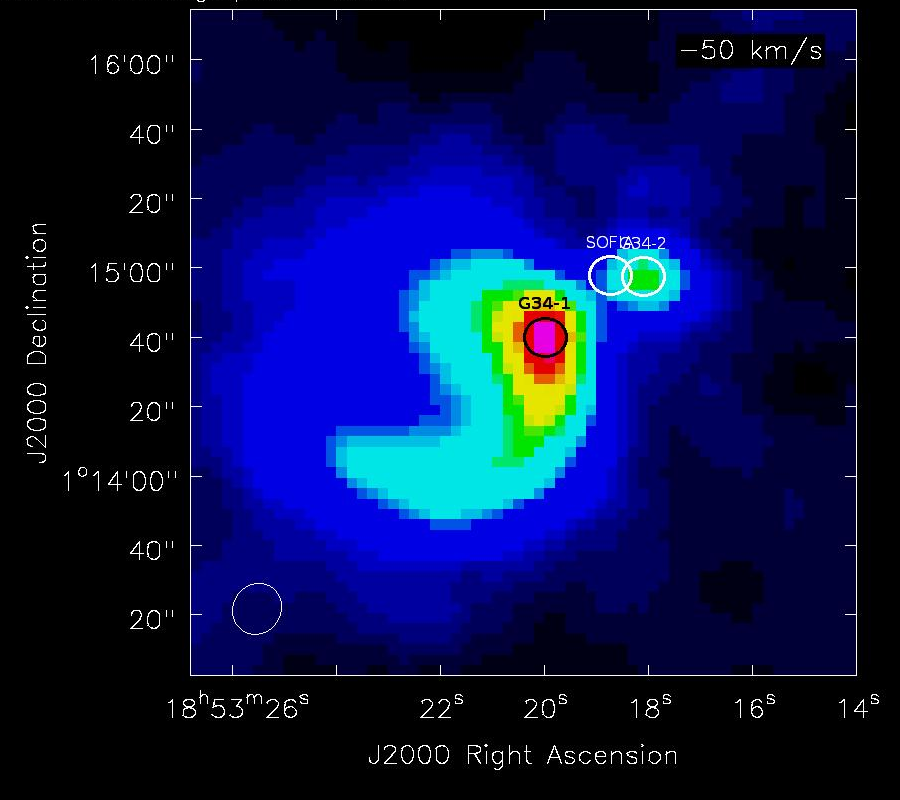

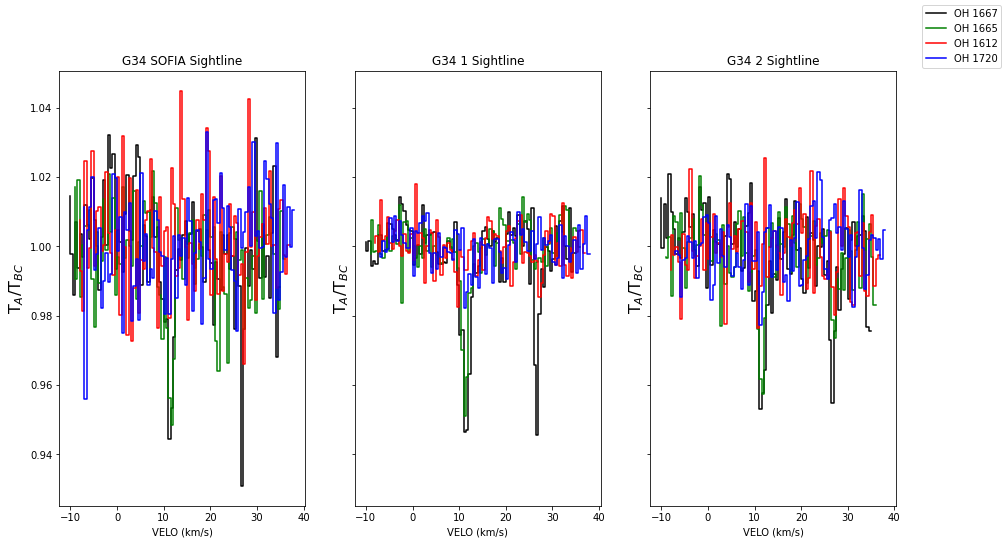

In [7]:
# Plot the data:
fig, axs = plt.subplots(1,3, figsize=(15, 8), sharey='all', sharex='all')

# Plot the xx:
axs[0].step(vel67s, Ta67s/np.median(Ta67s), 'k', label='OH 1667')
axs[0].step(vel65s, Ta65s/np.median(Ta65s), 'g', label='OH 1665')
axs[0].step(vel12s, Ta12s/np.median(Ta12s), 'r', label='OH 1612')
axs[0].step(vel20s, Ta20s/np.median(Ta20s), 'b', label='OH 1720')
axs[0].set_ylabel(r'T$_{A}$/T$_{BC}$', size=16)
axs[0].set_xlabel('VELO (km/s)')
axs[0].set_title('G34 SOFIA Sightline')

axs[1].step(vel671, Ta671/np.median(Ta671), 'k')
axs[1].step(vel651, Ta651/np.median(Ta651), 'g')
axs[1].step(vel121, Ta121/np.median(Ta121), 'r')
axs[1].step(vel201, Ta201/np.median(Ta201), 'b')
axs[1].set_ylabel(r'T$_{A}$/T$_{BC}$', size=16)
axs[1].set_xlabel('VELO (km/s)')
axs[1].set_title('G34 1 Sightline')

axs[2].step(vel672, Ta672/np.median(Ta672), 'k')
axs[2].step(vel652, Ta652/np.median(Ta652), 'g')
axs[2].step(vel122, Ta122/np.median(Ta122), 'r')
axs[2].step(vel202, Ta202/np.median(Ta202), 'b')
axs[2].set_ylabel(r'T$_{A}$/T$_{BC}$', size=16)
axs[2].set_xlabel('VELO (km/s)')
axs[2].set_title('G34 2 Sightline')

fig.legend()
fig.savefig('G34sightlines.png')

Image('ShallowClean/G34/G34.png')

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(10, 10), sharey='all', sharex='all')

# Plot the xx:
axs.step(vel671, Ta671/np.median(Ta671), 'k', label='OH 1667')
axs.step(vel651, Ta651/np.median(Ta651)+0.04, 'g', label='OH 1665')
axs.step(vel121, Ta121/np.median(Ta121)+0.07, 'r', label='OH 1612')
axs.step(vel201, Ta201/np.median(Ta201)+0.1, 'b', label='OH 1720')
axs.set_ylabel(r'T$_{A}$/T$_{BC}$', size=16)
axs.set_xlabel('VELO (km/s)')
axs.set_title('G34 1 Sightline')

fig.legend()
fig.savefig('G34-comparitive.png')

In [ ]:
# what is dv?
dv = 0.5

# Choose velocity range to calculate sideband temp.
vel67 = oh671['VELO (km/s)']
Ta67 = oh671['Ta (K)']
igood = np.where((vel67 >= -10) & (vel67 <= 0))

# Reload Data:
vel67 = vel67[igood]
Ta67 = Ta67[igood]

Tc = np.median(Ta67)
sigma = sigma = np.std((Ta67s - Tc)/Tc)

# Choose velocity range to integrate.
vel67 = oh671['VELO (km/s)']
Ta67 = oh671['Ta (K)']
igood = np.where((vel67 >= 22) & (vel67 <= 30))

Ta67 = Ta67[igood]
EW = np.sum(((Ta67-Tc)/Tc)*dv)
            
print("EW (km/s) is: " + str(np.sum(((Ta67-Tc)/Tc)*dv)))
print("EW (km/s) err is: " + str(sigma))

In [ ]:
### What is the column density?

k = 1 # 1 for 1667, 5/9 for 1665, 1/9 for 1612 and 1720.
Tex = 5
NOH = (EW * Tex)/ (0.45 * k)
NOH # 10-14
# 3.8e13

In [ ]:
# Choose velocity range.
igood67 = np.where((vel67s >= 22) & (vel67s<= 30))
igood65 = np.where((vel65s >= 22) & (vel65s<= 30))
igood12 = np.where((vel12s >= 22) & (vel12s<= 30))
igood20 = np.where((vel20s >= 22) & (vel20s<= 30))

# Choose a continuum.
igood67c = np.where((vel67s >= -10) & (vel67s <= 0))
igood65c = np.where((vel65s >= -10) & (vel65s <= 0))
igood12c = np.where((vel12s >= -10) & (vel12s <= 0))
igood20c = np.where((vel20s >= -10) & (vel20s <= 0))

peak67 = np.max(np.abs((Ta67s[igood67]-np.median(Ta67s[igood67c]))/np.median(Ta67s[igood67c])))
peak65 = np.max(np.abs((Ta65s[igood65]-np.median(Ta65s[igood65c]))/np.median(Ta65s[igood65c])))
peak12 = np.max(np.abs((Ta12s[igood12]-np.median(Ta12s[igood12c]))/np.median(Ta12s[igood12c])))
peak20 = np.max(np.abs((Ta20s[igood20]-np.median(Ta20s[igood20c]))/np.median(Ta20s[igood20c])))

print(peak67)
print(peak65)
print(peak12)
print(peak20)
print("err is +/- 0.001")

In [ ]:
# GaussianFit
gaussFit671_27 = models.Gaussian1D(amplitude=-0.04, mean=27*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit671_27 = fit(gaussFit671_27, vel671*u.km/u.s, (Ta671-np.median(Ta671[igood67c]))/np.median(Ta671[igood67c])*u.K)

#Predict the y values:
y_pred671_27 = y_fit671_27(vel671*u.km/u.s)

# parameters:
amp671_27 = y_fit671_27.amplitude[0]*u.K
mean671_27 = y_fit671_27.mean[0]*u.km/u.s
stddev671_27 = y_fit671_27.stddev[0]*u.km/u.s

# GaussianFit
gaussFit651_27 = models.Gaussian1D(amplitude=-0.02, mean=27*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit651_27 = fit(gaussFit651_27, vel651*u.km/u.s, (Ta651-np.median(Ta651[igood65c]))/np.median(Ta651[igood65c])*u.K)

#Predict the y values:
y_pred651_27 = y_fit651_27(vel651*u.km/u.s)

# parameters:
amp651_27 = y_fit651_27.amplitude[0]*u.K
mean651_27 = y_fit651_27.mean[0]*u.km/u.s
stddev651_27 = y_fit651_27.stddev[0]*u.km/u.s

# GaussianFit
gaussFit201_27 = models.Gaussian1D(amplitude=-0.02, mean=27*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit201_27 = fit(gaussFit201_27, vel201*u.km/u.s, (Ta201-np.median(Ta201[igood20c]))/np.median(Ta201[igood20c])*u.K)

#Predict the y values:
y_pred201_27 = y_fit201_27(vel201*u.km/u.s)

# parameters:
amp201_27 = y_fit201_27.amplitude[0]*u.K
mean201_27 = y_fit201_27.mean[0]*u.km/u.s
stddev201_27 = y_fit201_27.stddev[0]*u.km/u.s

# GaussianFit
gaussFit121_27 = models.Gaussian1D(amplitude=-0.01, mean=27*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit121_27 = fit(gaussFit121_27, vel121*u.km/u.s, (Ta121-np.median(Ta121[igood12c]))/np.median(Ta121[igood12c])*u.K)

#Predict the y values:
y_pred121_27 = y_fit121_27(vel121*u.km/u.s)

# parameters:
amp121_27 = y_fit121_27.amplitude[0]*u.K
mean121_27 = y_fit121_27.mean[0]*u.km/u.s
stddev121_27 = y_fit121_27.stddev[0]*u.km/u.s

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(10, 10), sharey='all', sharex='all')

# Plot the xx:
axs.step(vel671, (Ta671-np.median(Ta671))/np.median(Ta671), 'k', label='OH 1667')
axs.plot(vel671, y_pred671_27*u.K, color='k', ls='--', alpha=0.8)

axs.step(vel651, (Ta651-np.median(Ta651))/np.median(Ta651)+0.1, 'g', label='OH 1665')
axs.plot(vel651, y_pred651_27+0.1*u.K, color='g', ls='--', alpha=0.8)

axs.step(vel121, (Ta121-np.median(Ta121))/np.median(Ta121)+0.2, 'r', label='OH 1612')
axs.plot(vel121, y_pred121_27+0.2*u.K, color='r', ls='--', alpha=0.8)

axs.step(vel201, (Ta201-np.median(Ta201))/np.median(Ta201)+0.3, 'b', label='OH 1720')
axs.plot(vel201, y_pred201_27+0.3*u.K, color='b', ls='--', alpha=0.8)

axs.set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs.set_xlabel('VELO (km/s)')
axs.set_title('G34 27 km/s SOFIA Sightline ')
fig.legend()

In [ ]:
print("G34 27 km/s LOS Cloud")
print("Line -- Amp -- Center Velocity -- FWHM")
print("1720 " + str.format('{0:.3f}', amp201_27.value) + ' ' 
      + str.format('{0:.3f}',mean201_27.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev201_27.value))
print("1667 " + str.format('{0:.3f}', amp671_27.value) + ' ' 
      + str.format('{0:.3f}',mean671_27.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev671_27.value))
print("1665 " + str.format('{0:.3f}', amp651_27.value) + ' ' 
      + str.format('{0:.3f}',mean651_27.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev651_27.value))
print("1612 " + str.format('{0:.3f}', amp121_27.value) + ' ' 
      + str.format('{0:.3f}',mean121_27.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev121_27.value))

In [ ]:
EWfunc(Ta671, vel671, 27, 3, 0.5)

In [ ]:
# Solving directing for Tex
(0.001*0.45*1)/0.061

In [ ]:
EWfunc(Ta651, vel651, 27, 3, 0.5)

In [ ]:
# Solving directing for Tex
(0.001*0.45*(1/5))/0.009

In [ ]:
EWfunc(Ta121, vel121, 27, 3, 0.5)

In [ ]:
# Solving directing for Tex
(0.001*0.45*(1/9))/0.018

In [ ]:
EWfunc(Ta201, vel201, 27, 3, 0.5)

In [ ]:
# Solving directing for Tex
(0.001*0.45*(1/9))/-0.01

In [ ]:
# GaussianFit
gaussFit671_11 = models.Gaussian1D(amplitude=-0.04, mean=11*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit671_11 = fit(gaussFit671_11, vel671*u.km/u.s, (Ta671-np.median(Ta671[igood67c]))/np.median(Ta671[igood67c])*u.K)

#Predict the y values:
y_pred671_11 = y_fit671_11(vel671*u.km/u.s)

# parameters:
amp671_11 = y_fit671_11.amplitude[0]*u.K
mean671_11 = y_fit671_11.mean[0]*u.km/u.s
stddev671_11 = y_fit671_11.stddev[0]*u.km/u.s

# GaussianFit
gaussFit651_11 = models.Gaussian1D(amplitude=-0.02, mean=11*u.km/u.s, stddev=1*u.km/u.s)

# 2nd Fit:
y_fit651_11 = fit(gaussFit651_11, vel651*u.km/u.s, (Ta651-np.median(Ta651[igood65c]))/np.median(Ta651[igood65c])*u.K)

#Predict the y values:
y_pred651_11 = y_fit651_11(vel651*u.km/u.s)

# parameters:
amp651_11 = y_fit651_11.amplitude[0]*u.K
mean651_11 = y_fit651_11.mean[0]*u.km/u.s
stddev651_11 = y_fit651_11.stddev[0]*u.km/u.s

# GaussianFit
gaussFit201_11 = models.Gaussian1D(amplitude=-0.02, mean=11*u.km/u.s, stddev=0.5*u.km/u.s)

# 2nd Fit:
y_fit201_11 = fit(gaussFit201_11, vel201*u.km/u.s, (Ta201-np.median(Ta201[igood20c]))/np.median(Ta201[igood20c])*u.K)

#Predict the y values:
y_pred201_11 = y_fit201_11(vel201*u.km/u.s)

# parameters:
amp201_11 = y_fit201_11.amplitude[0]*u.K
mean201_11 = y_fit201_11.mean[0]*u.km/u.s
stddev201_11 = y_fit201_11.stddev[0]*u.km/u.s

# GaussianFit
gaussFit121_11 = models.Gaussian1D(amplitude=-0.01, mean=11*u.km/u.s, stddev=0.5*u.km/u.s)

# 2nd Fit:
y_fit121_11 = fit(gaussFit121_11, vel121*u.km/u.s, (Ta121-np.median(Ta121[igood12c]))/np.median(Ta121[igood12c])*u.K)

#Predict the y values:
y_pred121_11 = y_fit121_11(vel121*u.km/u.s)

# parameters:
amp121_11 = y_fit121_11.amplitude[0]*u.K
mean121_11 = y_fit121_11.mean[0]*u.km/u.s
stddev121_11 = y_fit121_11.stddev[0]*u.km/u.s

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(10, 10), sharey='all', sharex='all')

# Plot the xx:
axs.step(vel671, (Ta671-np.median(Ta671))/np.median(Ta671), 'k', label='OH 1667')
axs.plot(vel671, y_pred671_11, color='k', ls='--', alpha=0.8)

axs.step(vel651, (Ta651-np.median(Ta651))/np.median(Ta651)+0.1, 'g', label='OH 1665')
axs.plot(vel651, y_pred651_11+0.1*u.K, color='g', ls='--', alpha=0.8)

axs.step(vel121, (Ta121-np.median(Ta121))/np.median(Ta121)+0.2, 'r', label='OH 1612')
axs.plot(vel121, y_pred121_11+0.2*u.K, color='r', ls='--', alpha=0.8)

axs.step(vel201, (Ta201-np.median(Ta201))/np.median(Ta201)+0.3, 'b', label='OH 1720')
axs.plot(vel201, y_pred201_11+0.3*u.K, color='b', ls='--', alpha=0.8)

axs.set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs.set_xlabel('VELO (km/s)')
axs.set_title('G34 27 km/s SOFIA Sightline ')
fig.legend()

In [ ]:
print("G34 11 km/s LOS Cloud")
print("Line -- Amp -- Center Velocity -- FWHM")
print("1720 " + str.format('{0:.3f}', amp201_11.value) + ' ' 
      + str.format('{0:.3f}',mean201_11.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev201_11.value))
print("1667 " + str.format('{0:.3f}', amp671_11.value) + ' ' 
      + str.format('{0:.3f}',mean671_11.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev671_11.value))
print("1665 " + str.format('{0:.3f}', amp651_11.value) + ' ' 
      + str.format('{0:.3f}',mean651_11.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev651_11.value))
print("1612 " + str.format('{0:.3f}', amp121_11.value) + ' ' 
      + str.format('{0:.3f}',mean121_11.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev121_11.value))

In [ ]:
EWfunc(Ta671, vel671, 11.5, 5, 0.5)

In [ ]:
# Solving directing for Tex
(1.34*0.45*1)/0.12

In [ ]:
EWfunc(Ta651, vel651, 11.5, 5, 0.5)

In [ ]:
# Solving directing for Tex
(1.34*0.45*(1/5))/0.085

In [ ]:
EWfunc(Ta121, vel121, 11.5, 5, 0.5)

In [ ]:
# Solving directing for Tex
(1.34*0.45*(1/9))/0.03

In [ ]:
EWfunc(Ta201, vel201, 11.5, 5, 0.5)

In [ ]:
# Solving directing for Tex
(1.34*0.45*(1/9))/0.036

In [ ]:
# Attempt to loading the SOFIA data:
ohsof = ascii.read('ASCII_data_files/ASCII_data_files/G34P26_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Column"])

TaSof = ohsof["Column"]
VelSof = ohsof["Velo"]

# Choose velocity range.
igood = np.where((VelSof >= -10) & (VelSof <= 35))

TaSof = ohsof["Column"][igood]
VelSof = ohsof["Velo"][igood]

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(10, 10))

# Plot the xx:
axs.step(VelSof, TaSof, 'k', label='OH Column')

In [ ]:
# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof-8.2)/8.2, 'k', label='OH 2.5 THz')
axs[0].axvline(11, ls='dashed', alpha=0.8, color='r')
axs[0].axvline(27, ls='dashed', alpha=0.8, color='r')
axs[0].legend(loc='best')

axs[1].step(vel671, (Ta671-np.median(Ta671))/np.median(Ta671), 'k', label='OH 1667')
axs[1].plot(vel671, y_pred671_11, color='r', ls='--', alpha=0.8)
axs[1].plot(vel671, y_pred671_27, color='r', ls='--', alpha=0.8)
axs[1].axhline(0, color='k', ls='dashed')
axs[1].legend(loc='best')

axs[2].step(vel651, (Ta651-np.median(Ta651))/np.median(Ta651), 'k', label='OH 1665')
axs[2].plot(vel651, y_pred651_11*u.K, color='r', ls='--', alpha=0.8)
axs[2].plot(vel651, y_pred651_27*u.K, color='r', ls='--', alpha=0.8)
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].legend(loc='best')

axs[3].step(vel121, (Ta121-np.median(Ta121))/np.median(Ta121), 'k', label='OH 1612')
axs[3].plot(vel121, y_pred121_11*u.K, color='r', ls='--', alpha=0.8)
axs[3].plot(vel121, y_pred121_27*u.K, color='r', ls='--', alpha=0.8)
axs[3].axhline(0, color='k', ls='dashed')
axs[3].legend(loc='best')

axs[4].step(vel201, (Ta201-np.median(Ta201))/np.median(Ta201), 'k', label='OH 1720')
axs[4].plot(vel201, y_pred201_11*u.K, color='r', ls='--', alpha=0.8)
axs[4].plot(vel201, y_pred201_27*u.K, color='r', ls='--', alpha=0.8)
axs[4].axhline(0, color='k', ls='dashed')
axs[4].legend(loc='best')

plt.xlabel('Velocity (km/s)')
axs[0].set_title('G34P26+0.15')

fig.savefig('G34P26_fitted.png')

#Image('ShallowClean/w51/W51.png')

### Now we will plot W49N

In [10]:
# For W49N Sofia:
oh67s = ascii.read("ShallowClean/w49N/w49N.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=308)
oh65s = ascii.read("ShallowClean/w49N/w49N.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh12s = ascii.read("ShallowClean/w49N/w49N.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh20s = ascii.read("ShallowClean/w49N/w49N.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel67s = oh67s['VELO (km/s)']
Ta67s = oh67s['Ta (K)']
vel65s = oh65s['VELO (km/s)']
Ta65s = oh65s['Ta (K)']
vel12s = oh12s['VELO (km/s)']
Ta12s = oh12s['Ta (K)']
vel20s = oh20s['VELO (km/s)']
Ta20s = oh20s['Ta (K)']

# Choose velocity range.
igood67 = np.where((vel67s >= 35) & (vel67s <= 100))
igood65 = np.where((vel65s >= 35) & (vel65s <= 100))
igood12 = np.where((vel12s >= 35) & (vel12s <= 100))
igood20 = np.where((vel20s >= 35) & (vel20s <= 100))

# Choose a continuum.
igood67c = np.where((vel67s >= 70) & (vel67s <= 100))
igood65c = np.where((vel65s >= 70) & (vel65s <= 100))
igood12c = np.where((vel12s >= 70) & (vel12s <= 100))
igood20c = np.where((vel20s >= 70) & (vel20s <= 100))

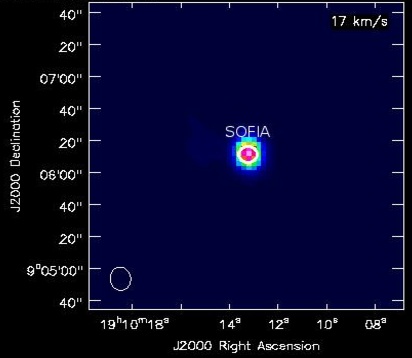

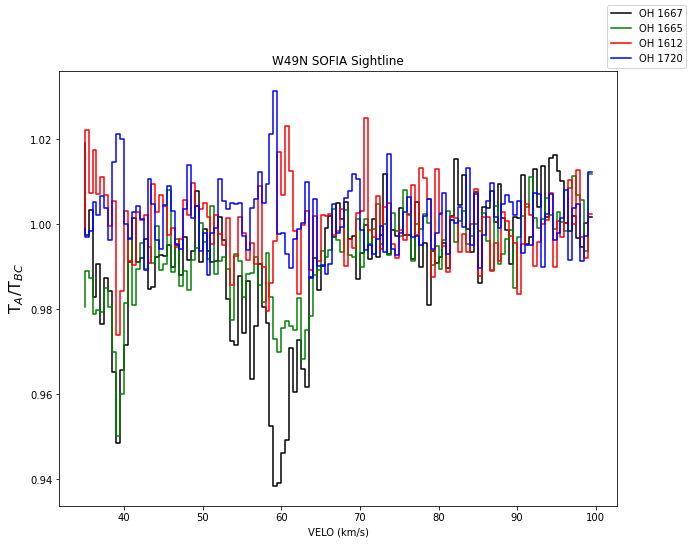

In [11]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(10, 8), sharey='all', sharex='all')

# Plot the xx:
axs.step(vel67s[igood67], Ta67s[igood67]/np.median(Ta67s[igood67c]), 'k', label='OH 1667')
axs.step(vel65s[igood65], Ta65s[igood65]/np.median(Ta65s[igood65c]), 'g', label='OH 1665')
axs.step(vel12s[igood12], Ta12s[igood12]/np.median(Ta12s[igood12c]), 'r', label='OH 1612')
axs.step(vel20s[igood20], Ta20s[igood20]/np.median(Ta20s[igood20c]), 'b', label='OH 1720')
axs.set_ylabel(r'T$_{A}$/T$_{BC}$', size=16)
axs.set_xlabel('VELO (km/s)')
axs.set_title('W49N SOFIA Sightline')


fig.legend()
fig.savefig('w49Nsightlines.png')

Image('ShallowClean/w49N/w49N.png')

#### Looks like 2 components, one at 40 km/s and another at 60 km/s.
#### We'll fit the 40 km/s one first:

In [ ]:
# Choose velocity range to calculate sideband temp.
vel67s = oh67s['VELO (km/s)']
Ta67s = oh67s['Ta (K)']
igood = np.where((vel67s >= 70) & (vel67s <= 100))

# what is dv?
dv = np.abs(vel67s[0] - vel67s[1])

# Reload Data:
vel67s = vel67s[igood]
Ta67s = Ta67s[igood]

Tc = np.median(Ta67s)
sigma = np.std((Ta67s - Tc)/Tc)

# Choose velocity range to integrate.
vel67s = oh67s['VELO (km/s)']
Ta67s = oh67s['Ta (K)']
igood = np.where((vel67s >= 50) & (vel67s <= 70))

Ta67s = Ta67s[igood]
EW = np.sum(((Ta67s-Tc)/Tc)*dv)

print("EW (km/s) is: " + str(EW))
print("err is " + str(sigma))

In [ ]:
sigma

In [ ]:
Tc

In [ ]:
# Reload 
vel67s = oh67s['VELO (km/s)']
Ta67s = oh67s['Ta (K)']
vel65s = oh65s['VELO (km/s)']
Ta65s = oh65s['Ta (K)']
vel12s = oh12s['VELO (km/s)']
Ta12s = oh12s['Ta (K)']
vel20s = oh20s['VELO (km/s)']
Ta20s = oh20s['Ta (K)']

# Plotting Range
igood67 = np.where((vel67s >= 35) & (vel67s <= 100))
igood65 = np.where((vel65s >= 35) & (vel65s <= 100))
igood20 = np.where((vel20s >= 35) & (vel20s <= 100))
igood12 = np.where((vel12s >= 35) & (vel12s <= 100))

# Science Integration Range
igood67i = np.where((vel67s >= 50) & (vel67s <= 70))
igood65i = np.where((vel65s >= 50) & (vel65s <= 70))
igood20i = np.where((vel20s >= 50) & (vel20s <= 70))
igood12i = np.where((vel12s >= 50) & (vel12s <= 70))

# Choose a continuum.
igood67c = np.where((vel67s >= 70) & (vel67s <= 100))
igood65c = np.where((vel65s >= 70) & (vel65s <= 100))
igood12c = np.where((vel12s >= 70) & (vel12s <= 100))
igood20c = np.where((vel20s >= 70) & (vel20s <= 100))

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(10, 10), sharey='all', sharex='all')

# Plot the xx:
axs.step(vel67s[igood67], (Ta67s[igood67]-np.median(Ta67s[igood67c]))/np.median(Ta67s[igood67c]), 'k', label='OH 1667')
axs.step(vel65s[igood65], (Ta65s[igood65]-np.median(Ta65s[igood65c]))/np.median(Ta65s[igood65c])+0.05, 'g', label='OH 1665')
axs.step(vel12s[igood12], (Ta12s[igood12]-np.median(Ta12s[igood12c]))/np.median(Ta12s[igood12c])+0.1, 'r', label='OH 1612')
axs.step(vel20s[igood20], (Ta20s[igood20]-np.median(Ta20s[igood20c]))/np.median(Ta20s[igood20c])+0.15, 'b', label='OH 1720')
axs.axvline(55)
axs.axvline(59)
axs.axvline(62)
axs.set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs.set_xlabel('VELO (km/s)')
axs.set_title('W49N SOFIA Sightline')

fig.legend()
fig.savefig('W49NSightlines-comparitive.png')

In [ ]:
peak67 = np.max(np.abs((Ta67s[igood67i]-np.median(Ta67s[igood67c]))/np.median(Ta67s[igood67c])))
peak65 = np.max(np.abs((Ta65s[igood65i]-np.median(Ta65s[igood65c]))/np.median(Ta65s[igood65c])))
peak12 = np.max(np.abs((Ta12s[igood12i]-np.median(Ta12s[igood12c]))/np.median(Ta12s[igood12c])))
peak20 = np.max(np.abs((Ta20s[igood20i]-np.median(Ta20s[igood20c]))/np.median(Ta20s[igood20c])))

print(peak67)
print(peak65)
print(peak12)
print(peak20)
print("err is +/- 0.001")

In [ ]:
# Choose velocity range to calculate sideband temp.
#vel67s = oh20s['VELO (km/s)']
#Ta67s = oh20s['Ta (K)']
#igood = np.where((vel67s >= 70) & (vel67s <= 100))

# Reload Data:
#vel67s = vel67s[igood]
#Ta67s = Ta67s[igood]

#Tc = np.median(Ta67s)

# Choose velocity range to integrate.
#vel67s = oh20s['VELO (km/s)']
#Ta67s = oh20s['Ta (K)']
#dv = np.abs(vel67s[0] - vel67s[1])
#igood = np.where((vel67s >= 50) & (vel67s <= 70))

#Ta67s = Ta67s[igood]
#EW = np.sum(((Ta67s-Tc)/Tc)*dv)

#print("EW (km/s) is: " + str(EW))

In [ ]:
### What is the column density?

#k = 1 # 1 for 1667, 5/9 for 1665, 1/9 for 1612 and 1720.
#Tex = 5
#NOH = (EW * Tex)/ (0.45 * k)
#NOH # 10-14
# 7e-13

In [ ]:
# GaussianFit
gaussFit67s = models.Gaussian1D(amplitude=-0.04, mean=39*u.km/u.s, stddev=0.5*u.km/u.s)

# 2nd Fit:
y_fit67s = fit(gaussFit67s, vel67s*u.km/u.s, (Ta67s-np.median(Ta67s[igood67c]))/np.median(Ta67s[igood67c])*u.K)

#Predict the y values:
y_pred67s = y_fit67s(vel67s[igood67]*u.km/u.s)

# parameters:
amp67s = y_fit67s.amplitude[0]*u.K
mean67s = y_fit67s.mean[0]*u.km/u.s
stddev67s = y_fit67s.stddev[0]*u.km/u.s

# GaussianFit
gaussFit65s = models.Gaussian1D(amplitude=-0.04, mean=39*u.km/u.s, stddev=0.5*u.km/u.s)

# 2nd Fit:
y_fit65s = fit(gaussFit65s, vel65s*u.km/u.s, (Ta65s-np.median(Ta65s[igood65c]))/np.median(Ta65s[igood65c])*u.K)

#Predict the y values:
y_pred65s = y_fit65s(vel65s[igood65]*u.km/u.s)

# parameters:
amp65s = y_fit65s.amplitude[0]*u.K
mean65s = y_fit65s.mean[0]*u.km/u.s
stddev65s = y_fit65s.stddev[0]*u.km/u.s

# GaussianFit
gaussFit20s = models.Gaussian1D(amplitude=0.02, mean=39*u.km/u.s, stddev=0.5*u.km/u.s)

# 2nd Fit:
y_fit20s = fit(gaussFit20s, vel20s*u.km/u.s, (Ta20s-np.median(Ta20s[igood20c]))/np.median(Ta20s[igood20c])*u.K)

#Predict the y values:
y_pred20s = y_fit20s(vel20s[igood20]*u.km/u.s)

# parameters:
amp20s = y_fit20s.amplitude[0]*u.K
mean20s = y_fit20s.mean[0]*u.km/u.s
stddev20s = y_fit20s.stddev[0]*u.km/u.s

# GaussianFit
gaussFit12s = models.Gaussian1D(amplitude=-0.02, mean=39*u.km/u.s, stddev=0.5*u.km/u.s)

# 2nd Fit:
y_fit12s = fit(gaussFit12s, vel12s*u.km/u.s, (Ta12s-np.median(Ta12s[igood12c]))/np.median(Ta12s[igood12c])*u.K)

#Predict the y values:
y_pred12s = y_fit12s(vel12s[igood12]*u.km/u.s)

# parameters:
amp12s = y_fit12s.amplitude[0]*u.K
mean12s = y_fit12s.mean[0]*u.km/u.s
stddev12s = y_fit12s.stddev[0]*u.km/u.s

In [ ]:
# Multiple Gaussian fit to the broad component:

# GaussianFit
#gaussFit67s = models.Gaussian1D(amplitude=-0.04, mean=39*u.km/u.s, stddev=0.5*u.km/u.s)

nGaussians = models.Gaussian1D(0, 56, 1) + models.Gaussian1D(0, 59, 1) + models.Gaussian1D(0, 62, 1)

yfit67s_55 = fit(nGaussians, vel67s*u.km/u.s, (Ta67s-np.median(Ta67s[igood67c]))/np.median(Ta67s[igood67c])*u.K)
yfit65s_55 = fit(nGaussians, vel65s*u.km/u.s, (Ta65s-np.median(Ta65s[igood65c]))/np.median(Ta65s[igood65c])*u.K)
yfit12s_55 = fit(nGaussians, vel12s*u.km/u.s, (Ta12s-np.median(Ta12s[igood12c]))/np.median(Ta12s[igood12c])*u.K)
yfit20s_55 = fit(nGaussians, vel20s*u.km/u.s, (Ta20s-np.median(Ta20s[igood20c]))/np.median(Ta20s[igood20c])*u.K)

#Predict the y values:
y_pred67s_55 = yfit67s_55(vel67s[igood67]*u.km/u.s)
y_pred65s_55 = yfit65s_55(vel65s[igood65]*u.km/u.s)
y_pred12s_55 = yfit12s_55(vel12s[igood12]*u.km/u.s)
y_pred20s_55 = yfit20s_55(vel20s[igood20]*u.km/u.s)

In [ ]:
yfit67s_55

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(10, 10), sharey='all', sharex='all')

# Plot the xx:
axs.step(vel67s[igood67], (Ta67s[igood67]-np.median(Ta67s[igood67c]))/np.median(Ta67s[igood67c]), 'k', label='OH 1667')
axs.plot(vel67s[igood67], y_pred67s, color='k', ls='--', alpha=0.8)
axs.plot(vel67s[igood67], y_pred67s_55, color='k', ls='--', alpha=0.8)

axs.step(vel65s[igood65], (Ta65s[igood65]-np.median(Ta65s[igood65c]))/np.median(Ta65s[igood65c])+0.1, 'g', label='OH 1665')
axs.plot(vel65s[igood65], y_pred65s+0.1*u.K, color='g', ls='--', alpha=0.8)
axs.plot(vel65s[igood65], y_pred65s_55+0.1*u.K, color='g', ls='--', alpha=0.8)

axs.step(vel12s[igood12], (Ta12s[igood12]-np.median(Ta12s[igood12c]))/np.median(Ta12s[igood12c])+0.2, 'r', label='OH 1612')
axs.plot(vel12s[igood12], y_pred12s+0.2*u.K, color='r', ls='--', alpha=0.8)
axs.plot(vel65s[igood12], y_pred12s_55+0.2*u.K, color='r', ls='--', alpha=0.8)

axs.step(vel20s[igood20], (Ta20s[igood20]-np.median(Ta20s[igood20c]))/np.median(Ta20s[igood20c])+0.3, 'b', label='OH 1720')
axs.plot(vel20s[igood20], y_pred20s+0.3*u.K, color='b', ls='--', alpha=0.8)
axs.plot(vel65s[igood20], y_pred20s_55+0.3*u.K, color='b', ls='--', alpha=0.8)

axs.set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs.set_xlabel('VELO (km/s)')
axs.set_title('W49N SOFIA Sightline')

fig.legend()
fig.savefig('W49NSightlines-39_opticaldepth.png')

Image('ShallowClean/w49N/w49N.png')

In [ ]:
print("W49N 39km/s LOS Cloud")
print("Line -- Amp -- Center Velocity -- FWHM")
print("1720 " + str.format('{0:.3f}', amp20s.value) + ' ' 
      + str.format('{0:.3f}',mean20s.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev20s.value))
print("1667 " + str.format('{0:.3f}', amp67s.value) + ' ' 
      + str.format('{0:.3f}',mean67s.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev67s.value))
print("1665 " + str.format('{0:.3f}', amp65s.value) + ' ' 
      + str.format('{0:.3f}',mean65s.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev65s.value))
print("1612 " + str.format('{0:.3f}', amp12s.value) + ' ' 
      + str.format('{0:.3f}',mean12s.value) + ' ' 
      + str.format('{0:.3f}',2.235*stddev12s.value))

In [ ]:
EWfunc(Ta671, vel671, 11.5, 5, 0.5)

In [ ]:
# Attempt to loading the SOFIA data:
ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Choose velocity range.
igood = np.where((VelSof >= 30) & (VelSof <= 100))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

In [ ]:
# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof-8)/8, 'k', label='OH 2.5 THz')
axs[0].axvline(39, ls='dashed', color='r', alpha=0.8)
axs[0].legend(loc='best')

axs[1].step(vel67s[igood67], (Ta67s[igood67]-np.median(Ta67s[igood67c]))/np.median(Ta67s[igood67c]), 'k', label='OH 1667 MHz')
axs[1].plot(vel67s[igood67], y_pred67s, color='r', ls='--', alpha=0.8)
axs[1].plot(vel67s[igood67], y_pred67s_55, color='r', ls='--', alpha=0.8)
axs[1].axhline(0, color='k', ls='dashed')
axs[1].legend(loc='best')

axs[2].step(vel65s[igood65], (Ta65s[igood65]-np.median(Ta65s[igood65c]))/np.median(Ta65s[igood65c]), 'k', label='OH 1665 MHz')
axs[2].plot(vel65s[igood65], y_pred65s*u.K, color='r', ls='--', alpha=0.8)
axs[2].plot(vel65s[igood65], y_pred65s_55*u.K, color='r', ls='--', alpha=0.8)
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].legend(loc='best')

axs[3].step(vel12s[igood12], (Ta12s[igood12]-np.median(Ta12s[igood12c]))/np.median(Ta12s[igood12c]), 'k', label='OH 1612 MHz')
axs[3].plot(vel12s[igood12], y_pred12s*u.K, color='r', ls='--', alpha=0.8)
axs[3].plot(vel12s[igood12], y_pred12s_55*u.K, color='r', ls='--', alpha=0.8)
axs[3].legend(loc='best')

axs[4].step(vel20s[igood20], (Ta20s[igood20]-np.median(Ta20s[igood20c]))/np.median(Ta20s[igood20c]), 'k', label='OH 1720 MHz')
axs[4].plot(vel20s[igood20], y_pred20s*u.K, color='r', ls='--', alpha=0.8)
axs[4].plot(vel20s[igood20], y_pred20s_55*u.K, color='r', ls='--', alpha=0.8)
axs[4].axhline(0, color='k', ls='dashed')
axs[4].legend(loc='best')

plt.xlabel('Velocity (km/s)')
axs[0].set_title('W49N')

fig.savefig('W49N_fitted.png')

#Image('ShallowClean/w51/W51.png')

### Now let's do the last spectra, NGC 7538

In [ ]:
# For W49N Sofia:
oh67s = ascii.read("ShallowClean/ngc7538/ngc7538.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=808)
oh65s = ascii.read("ShallowClean/ngc7538/ngc7538.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=811, data_end=1610)
oh12s = ascii.read("ShallowClean/ngc7538/ngc7538.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=1613, data_end=2412)
oh20s = ascii.read("ShallowClean/ngc7538/ngc7538.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=2415, data_end=3214)

vel67s = oh67s['VELO (km/s)']
Ta67s = oh67s['Ta (K)']
vel65s = oh65s['VELO (km/s)']
Ta65s = oh65s['Ta (K)']
vel12s = oh12s['VELO (km/s)']
Ta12s = oh12s['Ta (K)']
vel20s = oh20s['VELO (km/s)']
Ta20s = oh20s['Ta (K)']

# Choose velocity range.
igood = np.where((vel67s >= -80) & (vel67s <= -30))

# Get data ranges:
vel67s = vel67s[igood]
Ta67s = Ta67s[igood]
vel65s = vel65s[igood]
Ta65s = Ta65s[igood]
vel12s = vel12s[igood]
Ta12s = Ta12s[igood]
vel20s = vel20s[igood]
Ta20s = Ta20s[igood]

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(10, 8), sharey='all', sharex='all')

# Plot the xx:
axs.step(vel67s, Ta67s/np.median(Ta67s), 'k', label='OH 1667')
axs.step(vel65s, Ta65s/np.median(Ta65s), 'g', label='OH 1665')
axs.step(vel12s, Ta12s/np.median(Ta12s), 'r', label='OH 1612')
axs.step(vel20s, Ta20s/np.median(Ta20s), 'b', label='OH 1720')
axs.set_ylim([0.8, 1.2])
axs.set_ylabel(r'T$_{A}$/T$_{BC}$', size=16)
axs.set_xlabel('VELO (km/s)')
axs.set_title('NGC 7538 SOFIA Sightline')


fig.legend()
fig.savefig('ngc7539_comparative.png')

Image('ShallowClean/ngc7538/ngc7538.png')

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(10, 8), sharey='all', sharex='all')

# Plot the xx:
axs.step(vel67s, Ta67s/np.median(Ta67s), 'k', label='OH 1667')
axs.step(vel65s, Ta65s/np.median(Ta65s), 'g', label='OH 1665')
axs.step(vel12s, Ta12s/np.median(Ta12s), 'r', label='OH 1612')
axs.step(vel20s, Ta20s/np.median(Ta20s), 'b', label='OH 1720')
axs.set_ylim([0.8, 2])
axs.set_ylabel(r'T$_{A}$/T$_{BC}$', size=16)
axs.set_xlabel('VELO (km/s)')
axs.set_title('NGC 7538 SOFIA Sightline')


fig.legend()
fig.savefig('ngc7538sqightlines.png')